Goal: Using multiple sequence alignment–derived features, 
we trained a machine learning model to predict whether positions in the SARS-CoV-2 Spike protein are 
prone to substitutions, insertions, or deletions.
    

In [1]:
pip install py3Dmol

Note: you may need to restart the kernel to use updated packages.


In [108]:
packages = """biopython
pandas
numpy
scipy
scikit-learn
matplotlib
seaborn
umap-learn
xgboost
tensorflow
blosum
"""

with open("requirements.txt", "w") as f:
    f.write(packages)

print("requirements.txt created")

requirements.txt created


In [112]:
#Libraries needed: 

# Biopython: parse, manipulate, and analyze biological data
from Bio import SeqIO,AlignIO
from Bio.Align import MultipleSeqAlignment
from Bio.PDB import PDBParser

# Python libraries:
import random as rd
import math
from collections import Counter

#sequence alignment
import subprocess

#Data Manipulation:
import pandas as pd
import numpy as np

#Visualization: 
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

#Statistics: 
from scipy.stats import entropy
import blosum as bl

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Unsupervised Models
from sklearn.decomposition import PCA
import umap.umap_ as umap

#Supervised Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRegressor
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold, 
    GridSearchCV,
    ParameterGrid
)
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error, 
    mean_squared_error
)

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

PHASE 1: Data frame creation

    - Read in Fasta files for sequences and reference sequence
    - Filter sequences:
            * X's -> unknown amino acids do not contribute to prediction
            * Duplicate sequences -> identical sequences under different id's which can inflate mutation artificially
    - Align combined dataset using MAFT
    - Change format from wide to long
    

In [3]:
#read the fasta file

def open_file(file,format):
    """The function parses downloaded reference sequences"""

    record = list(SeqIO.parse(file, format))
    return record

var_protein = open_file("virus_protein.fasta", format = "fasta") #2000 variant sequences
init_protein = open_file("wuhan_spike_YP_009724390.1.fasta", format = "fasta") #reference sequence

#var_protein
#init_protein

for rec in var_protein[ :3]: #just checking it printed the sequences
    print(rec.id)
    print(str(rec.seq[ :10]))
    print("-" * 60)

#MFVFLVLLPL
#MFVFLVLLPL
#MFVFLVLLPL


for rec in init_protein: #just checking it printed the sequences
    print(rec.id)
    print(str(rec.seq[ :10]))
    print("-" * 60)

#MFVFLVLLPL

WKQ99033.1
MFVFLVLLPL
------------------------------------------------------------
UEZ51942.1
MFVFLVLLPL
------------------------------------------------------------
XRW97038.1
MFVFLVLLPL
------------------------------------------------------------
YP_009724390.1
MFVFLVLLPL
------------------------------------------------------------


In [4]:
#sanity checks
# print(len(var_protein),len(init_protein))     # should be ~2000 Sars-COV-2 protein sequences; should be 1: Wuhan Reference Sequence
# print(var_protein[0].id,len(var_protein[0].seq),init_protein[0].id,len(init_protein[0].seq))

lengths = [len(rec.seq) for rec in var_protein]
min_len = min(lengths)
max_len = max(lengths)
# print(min_len,max_len)


Problem 1: Accounting for X's

Common One-Letter Amino Acid Codes (20 codes - "Safe" for prediction) :)
- A: Alanine
- R: Arginine
- N: Asparagine
- D: Aspartic acid
- C: Cysteine
- Q: Glutamine
- E: Glutamic acid
- G: Glycine
- H: Histidine
- I: Isoleucine
- L: Leucine
- K: Lysine
- M: Methionine
- F: Phenylalanine
- P: Proline
- S: Serine
- T: Threonine
- W: Tryptophan
- Y: Tyrosine
- V: Valine

(ARNDCQEGHILKMFPSTWYV)

X: unknown/ambigious amino acid (1 code - "Danger" for prediction) :(

In [5]:
#We need to filter out the sequences with large chunks of X's because those are unknown amino acids, 
#cannot predict mutations with large proportions of unknown amino acids

def normalize(seq):
    norm_seq = seq.upper().replace("*", "").replace("-", "").strip() #accounts for unnecessary characters like stop symbols
    return norm_seq
    
valid_aa = {
    "A","R","N","D","C","Q","E","G","H","I",
    "L","K","M","F","P","S","T","W","Y","V","X"
}

def valid_aa_seq(seq,max_x = 0.02):
    
    seq = normalize(seq)
    length = len(seq)

    if length == 0:
        return False

    if seq.count("X") / length > max_x: #checks if counts of "X's" are larger than threshold 0.02
        return False

    return True
  
#valid_aa_seq("ACDXFGHIK",max_x) False

In [109]:
#apply filtering function to 2000 sequences T.T
max_x = 0.02
keep_seq = []
out_seq = []

for rec in var_protein:
    if valid_aa_seq(rec.seq,max_x=0.02):
        keep_seq.append(rec)
        
    else:
         out_seq.append(rec)

print("Valid sequences:", len(keep_seq))
print("Invalid sequences:", len(out_seq))

Valid sequences: 1491
Invalid sequences: 509


In [7]:
#examine which sequences we should keep
def seqrecords_to_df(records):
    """
    Convert a list of Bio.SeqRecord objects into a pandas DataFrame.
    """
    rows = []

    for rec in records:
        seq = normalize(str(rec.seq))
        rows.append({
            "id": rec.id,
            "description": rec.description,
            "sequence": seq,
            "length": len(seq),
            "X_count": seq.count("X"),
            "X_fraction": seq.count("X") / len(seq) if len(seq) > 0 else 0
        })

    return pd.DataFrame(rows)

keep_seq_df = seqrecords_to_df(keep_seq)
keep_seq_df.to_csv("keep_sequences.csv", index=False)

In [111]:
#Remove Duplicate Sequences under different Ids
unique_set = {}

for rec in keep_seq:
    norm_seq = normalize(rec.seq) 
    if norm_seq not in unique_set: 
        unique_set[norm_seq] = rec

unique_rec = list(unique_set.values())

seqs = [normalize(rec.seq) for rec in unique_rec]
# print(len(seqs), len(set(seqs))) #set says give me unique sequence strings only, numbers should match if duplicates removed

valid_df = seqrecords_to_df(unique_rec)
valid_df.to_csv("valid_seq.csv", index=False)
print("Valid sequences:", len(valid_df))

Valid sequences: 650


In [9]:
#unique_set of sequences we need 50
rd.seed(42)

sample_protein = rd.sample(unique_rec,50)
print(len(sample_protein))

seq_strings = [normalize(rec.seq) for rec in sample_protein]

# print("Total sequences:", len(seq_strings))
# print("Unique sequences:", len(set(seq_strings))) #some identical sequences

counts = Counter(seq_strings)
duplicates = {seq: c for seq, c in counts.items() if c > 1}

len(duplicates)

protein_df = seqrecords_to_df(sample_protein)
protein_df.to_csv("protein_df.csv", index=False)

50


In [10]:
#save as fasta file so its reproducible 
def sample_spikes(sample,file_name,format):
    """This function saves the sample set of proteins to a fasta file"""
    
    SeqIO.write(sample,file_name,format)
    return file_name
    

sample_spikes(sample_protein,"sample_protein50.fasta",format = "fasta")

#sanity checks 
protein_50 = open_file("sample_protein50.fasta", format = "fasta")
# print(len(protein_50)) #~50 random sequences

lengths = [len(rec.seq) for rec in protein_50]
min_len = min(lengths)
max_len = max(lengths)

# print(min_len)
# print(max_len)

2. Next we need run Multiple Sequence Alignment. (google colab used)
   
This puts them in identical postitions to the each other, some sequence positions are off due to insertions and deletions
Therefore, it is easier to see which type of mutation each sequence has.


What MSA is actually doing:

Column i represents the same evolutionary position across all sequences. Now each column is biologically meaningful since all gaps are accounted for and all sequences will be of the same length

- Gaps(-) encode insertion/deletions 
- substitutions are obvious (non-consensus letters A -> G [wrong letter])
  
After MSA: - we will get a matrix rows: seq id and cols: position and residue (letter in cell)

- We need to have each residue in its own cell with:
   - row = sequence 
   - col = residue and position in sequence relative to the wuhan  sequence

In [11]:
#build data frame of 50 random sequences and reference wuhan strain 

#1. combine reference Wuhan strain [0] with the 50 sample sequences
ref_record = init_protein[0]  # wuhan spike record
ref_record.id = "WUHAN_REF"
combined = [ref_record] + sample_protein # data types match so i can just +, creates a new list with both the lists
# print(len(combined)) # ~ 51

#2. save in fasta file
combined_50ref = sample_spikes(combined,"combined_50ref.fasta",format = "fasta") 

In [12]:
#3. Align with MAFFT
combined_50ref_aligned = open_file("combined_50ref_aligned.fasta",format = "fasta")

#sanity check
# print(len(combined_50ref_aligned))            # should be 51
# print(combined_50ref_aligned[0].id)           # Wuhan
# print(len(combined_50ref_aligned[0].seq))     # alignment length wuhan
# print(len(combined_50ref_aligned[1].seq))     # alignment length random sequence

In [13]:
#4. Put into a dataframe
data = {}
for rec in combined_50ref_aligned:
    data[rec.id] = list(str(rec.seq))

df_wide = pd.DataFrame.from_dict(data, orient="index")

In [14]:
#wide format dataframe with sequences stacked 
df = pd.DataFrame({
    "id": [rec.id for rec in combined_50ref_aligned],
    "seq": [list(str(rec.seq)) for rec in combined_50ref_aligned]
})
#df

#wide format that we want
seq_df = pd.DataFrame(df["seq"].tolist())

#put it together
seq_df.index = df["id"]
seq_df.index.name = "seq_id"

3. Change format of dataframe to long so each residue/nucleotide is next to reference strain


In [15]:
#change to long format 
wide = seq_df.copy()
#wide.head()

wide = wide.reset_index().rename(columns={"index":"seq_id"})
wide.head()

#pd.melt()        # long
#df.pivot()       # wide (no duplicates)
#df.pivot_table() # wide (with aggregation)

#melt: take each column and pour it down into rows, hence melt
long = wide.melt(
    id_vars = "seq_id", #keep seq_id as is
    var_name = "aln_index", #take col names 0-1280 and put them in a new col called aln_index
    value_name = "sample_residue" #take the residue values and put them in a new col called sample_residue
)

In [16]:
#identify wuhan id and store it
wuhan_id = "WUHAN_REF"

#.loc : find something by its label (name) 
#.iloc: find something by its position row number

#select the reference id
wuhan_row = seq_df.loc[wuhan_id] #give me row of reference sequence, we know sequence name is safer to use

#how it should look 
#seq_id	aln_index	sample_residue	wuhan_residue
#S1      	0	          M    	        M
#S1	        1	          F         	F
#S1	        2	          I         	V

#make a cheat sheet for reference
wuhan_map = wuhan_row.to_dict() #can identify what is the wuhan residue at pos i 

#.map for every seq look at the pos i and check the cheat sheet and write the wuhan letter in a "wuhan_residue"
long["wuhan_residue"] = long["aln_index"].map(wuhan_map)
long = long[long["seq_id"] != "WUHAN_REF"].copy() #remove redundant wuhan vs wuhan rows

print(len(long))

63950


PHASE 2: Predictor/Pre-processing

    - Data in long format
    - Identify predictors
    - Create corresponding functions or summaries for the 20+ features
    - Identify mutations 
    - Determine hotspot definition for prediction: threshold vs shannon entropy -> start with threshold mut_rate > 0.05 maybe add entropy later (Response)
    - Encode features (dummy,levels, numeric, categorical, etc.) 
    - missing values (X's and "-" [gaps]) -> how to address? small proportions maybe drop, if specific positions are large in X or - maybe drop position

In [17]:
#make a copy of analysis dataset
seq1_df = long.copy()
seq1_df.to_csv("seq1_df.csv", index=False)

1. we need to identify the mutations as 0 = stable, 1 = substitution, 2 = deletion, 3 = insertion 
    - stable (no mutation): ref - AA and seq - AA 
    - substitution: ref - AA and seq - GG 
    - deletion: ref - AA and seq - "-" 
    - insertion: ref - "-" and seq - AA

A mutation hotspot is a reference alignment position that mutates frequently across sequences (variants).

Identifying mutation-prone positions given observed variation

In [18]:
#define classes for mutations

valid_aa = set("ARNDCQEGHILKMFPSTWYV") #valid amino acids counted for mutations

def mutations(ref,seq):

    ref = str(ref).upper()
    seq = str(seq).upper()
    
    # if unknown AA
    if ref == "X" or seq == "X":
        return None
    # if both gaps -> nonexistent structure
    if ref == "-" and seq == "-":
        return None

    # if aa not in valid set
    if (ref not in valid_aa and ref != "-") or (seq not in valid_aa and seq != "-"):
        return None 

# mutation identification: 
    
    # stable (same amino acid, both real) 
    if ref == seq and ref != "-":
        return 0
    
    # substitution (both real, different)
    if ref != "-" and seq != "-" and ref != seq:
        return 1
    
    # deletion (reference has AA, sample has gap)
    if ref != "-" and seq == "-":
        return 2
    
    # insertion (reference has gap, sample has AA)
    if ref == "-" and seq != "-":
        return 3



# print("mutation:",mutations("A","A"))  # get mutation = 0 
# print("mutation:" ,mutations("A","G")) # get mutation = 1
# print("mutation:",mutations("A","-"))  # get mutation = 2
# print("mutation:",mutations("-","A"))  # get mutation = 3 
# print("mutation:",mutations("-","-"))  # get mutation = None since both sequence nucleotides are missing

In [19]:
# use mutation function to identify mutations from dataframe long

seq1_df["mutation"] = seq1_df.apply(
    lambda r: mutations(r["wuhan_residue"],r["sample_residue"]),
    axis = 1 #axis = 1 compare within same row; axis = 0 summarize/compare in same column so it wouldnt work in this case and provide wrong mutations
)
seq1_df.to_csv("seq1_df.csv", index=False)

In [20]:
mutation_seq1_df = seq1_df.copy()
mutation_seq1_df.to_csv("mutation_seq1_df.csv",index = False)


missing = mutation_seq1_df["mutation"].isna().sum()
num_unknowns = (mutation_seq1_df["sample_residue"] == "X").sum()
tot_prop_missunk = mutation_seq1_df["mutation"].isna().sum() + (mutation_seq1_df["mutation"] == "Unknown").sum()
print(len(mutation_seq1_df),
      "missing:", missing," ",
      "Total unknown residues (X):", num_unknowns," "
      "Total prop of unknown and missing residues:", tot_prop_missunk/len(mutation_seq1_df)
     )

63950 missing: 383   Total unknown residues (X): 101  Total prop of unknown and missing residues: 0.005989053948397186


In [21]:
#Response function Hotspots :D (attempt 1) 

# def hotspot(df, max_thresh=0.05):
#     """
#     Computes mutation rate per alignment position.
#     If mutation rate > max_thresh, it is considered a hotspot.
#     """
#     results = {}

#     aln_indices = df["aln_index"].unique()
#     total_seqs = df["seq_id"].nunique()

#     for pos in aln_indices:
#         pos_df = df[df["aln_index"] == pos]

#         mut_count = (pos_df["mutation"] != 0).sum()
#         mut_rate = mut_count / total_seqs

#         hotspot_label = 1 if mut_rate > max_thresh else 0

#         results[pos] = {"hotspot": hotspot_label}

#     return results


# # Run it
# hotspot_results = hotspot(seq1_df, max_thresh=0.05)

# # Map results back into columns
# seq1_df["hotspot"] = seq1_df["aln_index"].map(lambda x: hotspot_results[x]["hotspot"])

# # Save
# seq1_df.to_csv("seq1_df.csv", index=False)


def hotspot_label(df, max_thresh = 0.05):
    total_seqs = df["seq_id"].nunique()

    pos = (
        df.groupby("aln_index",as_index = False)
        .agg(mut_count = ("mutation",lambda s: s.isin([1,2,3]).sum()))
    )
    pos["mut_rate"] = pos["mut_count"]/total_seqs
    pos["hotspot"] = (pos["mut_rate"] > max_thresh).astype(int)
    return pos

In [22]:
pos_df = hotspot_label(seq1_df,max_thresh = 0.05)
seq1_df = seq1_df.merge(pos_df[["aln_index","hotspot"]], on = "aln_index", how = "left")
seq1_df.head(2)

,seq_id,aln_index,sample_residue,wuhan_residue,mutation,hotspot
0,QZW68578.1,0,M,M,0.0,0
1,QZI36305.1,0,M,M,0.0,0


In [23]:
seq1_df.to_csv("seq1_df.csv", index=False)

Predictors


A. Variation and uncertainty features

- Mutation frequency: measures counts and rates of mutations at each position
     - 0: stable
     - 1: substitution
     - 2: deletion
     - 3: insertion

- Shannon Entropy: measures variability of amino acids across sequences per position (i) (ignores X and gaps)
     - high: 4.32, an amino acid is more tolerant of mutations (more likely to undergo one)
     - low: 0, an amino acid is more resistant to mutations (more predictable)

- Number of distinct amino acids observed at that column
- Major allele frequency (frequency of most common residue per position) 
- Gap frequency ("-" fraction) -> indel prone regions/alignment uncertainty -> filtering
- Unknown frequency ("X" fraction) -> missingness indication (useful for confidence/filtering)
- Transition to/from gap count: how often sequences have "-" while ref is AA or vice versa -> indel tendency


B. Reference Amino-Acid identity and biochemical properties -> why this position might tolerate or attract change biologically

- RSA/ASA: surface exposure
- Hydrophobicity of reference residue (Kyle-Doolittle value)
- Charge class of reference residue (negative/positive/neutral)
- Polarity class (polar vs non-polar)
- Aromatic indicator (F/W/Y = 1 else 0)
- Proline indecation (P = 1) -> often structurally special
- Glycine indicator  (G = 1) -> flexibility

C. Local Context Features (Sequence neighborhood matters)

- Sliding-window entropy mean (i.e, mean entropy +- 5 residues)
- Local Composition in window (fraction hydrophobic in +- 5 residues)
- Local Proline/Glycine density in window (flexibility proxy)

D. "Functional Constraint" proxies from the data you already have

- Conservation Score (1-entropy or major allele frequency) - constraint proxy
- Amino-acid "exchangeability"/BLOSUM-based avg distance - compute mean BLOSUM62 score between ref residue and observed residues (lower = more radical changes tolerated or occurring.)

# mutation frequency 

counts overall mutations per position (attempt 1)

    def mut_freq(df):
     results = {}

     aln_indices = df["aln_index"].unique()

     for pos in aln_indices:
         pos_df = df[df["aln_index"] == pos]
         mut_freq = (pos_df["mutation"] != 0).sum()
         results[pos] = mut_freq

     return results
     
    #run
    mut_freq_results = mut_freq(seq1_df)
    #map to columns
    seq1_df["mut_freq"] = seq1_df["aln_index"].map(mut_freq_results)
    #save
    seq1_df.to_csv("seq1_df.csv", index=False)


mutation frequency and rate for each type of mutation (attempt 2: pls work T.T) 
     
     def mut_freq_type(df):
     results = []

     for pos, pos_df in df.groupby("aln_index"):
        
         #contains only mutations == 0,1,2,3
         pos_mut = pos_df[pos_df["mutation"].notna()] 
         pos_len = len(pos_mut)

         #add counts for each mutation
         stable_freq = (pos_mut["mutation"] == 0).sum()
         sub_freq = (pos_mut["mutation"] == 1).sum()
         del_freq = (pos_mut["mutation"] == 2).sum()
         ins_freq = (pos_mut["mutation"] == 3).sum()

         #add rates for each mutation
         stable_rate = stable_freq / pos_len if pos_len else 0 
         sub_rate = sub_freq / pos_len if pos_len else 0 
         del_rate =  del_freq / pos_len if pos_len else 0 
         ins_rate = ins_freq / pos_len if pos_len else 0 

         results.append({
             "stable_freq": stable_freq, "stable_rate": stable_rate,
             "sub_freq": sub_freq,"sub_rate": sub_rate,
             "del_freq": del_freq, "del_rate": del_rate,
             "ins_freq": sub_freq,"ins_rate": sub_freq,
         })
     return results

For the mutation frequency, we need to split up the frequency and rate for each mutation type

- Stable == 0 : one column is frequency and one column is rate
- Substitution == 1: one column is frequency and one column is rate
- Insertion == 2: one column is frequency and one column is rate
- Deletion == 3: one column is frequency and one column is rate

mutation freq = total number of mutations x == 1 or 2 or 3

mutation rate = mutation frequency / number of valid residues

In [24]:
# mutation frequency and rate for each type of mutation (attempt 3: Piping yay! you work :D ) 

#N = seq1_df["seq_id"].nunique() <- wrong :( need to account for only valid/callable residues

pos_rates = (
    seq1_df
    .groupby("aln_index") #.groupby -> %>% group_by in R
    .agg(  # %>% summarize() in R
        valid_n = ("mutation",lambda x: x.notna().sum()),
        mut_freq = ("mutation",lambda x: x.isin([1,2,3]).sum()),
        stable_freq = ("mutation", lambda x: (x == 0).sum()),
        sub_freq = ("mutation", lambda x: (x == 1).sum()),
        del_freq = ("mutation", lambda x: (x == 2).sum()),
        ins_freq = ("mutation", lambda x: (x == 3).sum()),
    )
    .assign(  #%>% mutate() in R
        mut_rate = lambda d: d.mut_freq / d.valid_n,
        stable_rate = lambda d: d.stable_freq / d.valid_n,
        sub_rate = lambda d: d.sub_freq / d.valid_n,
        del_rate = lambda d: d.del_freq / d.valid_n,
        ins_rate = lambda d: d.ins_freq / d.valid_n
    )
    .reset_index()
)

In [25]:
#merge it onto seq1_df
seq2_df = seq1_df.copy()

In [26]:
seq2_df = seq2_df.merge(pos_rates, on = "aln_index",how = "left")

In [27]:
# reorder columns
base_cols = ['seq_id', 'aln_index', 'sample_residue',
             'wuhan_residue', 'mutation', 'hotspot','valid_n']

ordered_mut_cols = [
    'mut_freq', 'mut_rate',
    'stable_freq', 'stable_rate',
    'sub_freq', 'sub_rate',
    'del_freq', 'del_rate',
    'ins_freq', 'ins_rate'
]

seq2_df = seq2_df[base_cols + ordered_mut_cols]

In [28]:
seq2_df.to_csv("seq2_df.csv", index=False)

# Shannon Entropy 

How unpredictable is the amino acid distribution here?

- If every sequence has the same residue -> low entropy
- If many different residues appear in similar proportions -> high entropy (variability of amino acids)

Formula: H = - summation[p_i * log_2(pi)]
 - where p_i = fraction of amino acid at that position -> total count of amino acid / total count of valid residues

- calculate shan_ent on the different amino acids in pos i 
- exclude gaps, X's, None because they do not contribute to variability of the residues


Shannon_entropy: (attempt 1 - With formula, but theres a package we could use :D)

 
     def shannon_entropy(residues): 
      # keep only valid amino acids
      residues = [r.upper() for r in residues if r and r.upper() in valid_residue]  

      #numerator/denmoinator
      count_aa = Counter(residues)
      total_aa = sum(count_aa.values())
      
      print(count_aa, total_aa) # check if den. is correct

     if total_aa == 0:
         return 0.0
     #shannon entropy formula
     H = 0.0
     for c in count_aa.values():
         p = c / total_aa
         H += p * math.log2(1 / p)   # same as -p*log2(p)
        
     return H

In [29]:
# identify what counts as a valid residue: 
valid_residue = set("ARNDCQEGHILKMFPSTWYV")

# create function using entropy from scipy package
def shannon_entropy(residues):
    # keep only valid amino acids
    residues = [r.upper() for r in residues if r and r.upper() in valid_residue]
    count_res = list(Counter(residues).values())

    if len(count_res) == 0:
        return None
    
    else:
        shan_ent = entropy(count_res, base=2)

    return float(shan_ent)

In [30]:
#print(shannon_entropy("ARADCX-TSAKKFP"),shannon_entropy("LLLMNS-TTESW")) 3.0220552088742005 2.663532754804255

In [31]:
entropy_df= (
    seq2_df
    .groupby("aln_index") #.groupby -> %>% group_by in R
    .agg(  # %>% summarize() in R
       shannon_entropy = ("sample_residue",lambda s: shannon_entropy(s.tolist()))
    )
    .reset_index()
)

In [32]:
seq2_df = seq2_df.merge(entropy_df, on = "aln_index",how = "left")

In [33]:
seq2_df.to_csv("seq2_df.csv", index=False)

# RSA/ASA Surface exposure: 

How much of this residue is accessible to solvent (water)?

Why? wuhan is my primary region of interest that im building from. My 50 sequences are kinda secondary. They are there to help determine mutations but we dont really care about their properties. We care about the wuhan because if those 50 sequences are similar (most are) we want to see if the wuhan structure is more resistant or prone, which i guess gets emphasized when there is a mutation in the 50 sequences (biological evolution). So the RSA is used because we are checking part of the structure of the wuhan sequence to see if its more expose; thus more likely to mutate.

Measured as: 

- ASA = Accessible surface area (A^2)
- RSA = Relative Solvent Accessibility = ASA/ max possible ASA  (0 <= RSA <= 1)

Biologically:

- Buried residues → structural core → conserved → mutate less
- Exposed residues → surface → interact with antibodies/receptors → mutate more

For Spike, this is especially relevant because immune pressure acts on exposed regions.

Most tools output RSA (Relative Solvent Accessibility) per residue:

- RSA ≈ 0.00–0.05 → buried/core 
- RSA ≈ 0.25+ → commonly treated as “exposed”
- RSA close to 1 → very exposed (loops, tips, edges)


Procedure:
1. Create a column of the positions of the Wuhan ref sequence with NA for the gaps (1,2,NA,3,4,etc)
2. Use NetSurfP which gives a downloadable csv/json file with the RSA of the reference sequence to quantify which parts have surface exposure
3. merge onto data frame


# q8: 8 - State Secondary Structure

idea: if structured, what secondary structure class does it belong to

corresponds to DSSP structural classes

- H:  alpha-helix (more constrained)
- G: 3_10 helix
- I: pi-helix (rare)
- E: beta-strand (sheet) (more constrained)
- B: beta-bridge
- T: turn (more flexible)
- S: bend
- C: coil/other (most flexible)

Secondary structures reflects: Backbone hydrogen bonding geometry and local folding constraints

- Helices and sheets are ordered and stabilized
- Loops, turns, bends are more flexible

Hotspots tend to occur when: structure is flexible, residue identity can change without breaking backbone geometry, and surface loops are exposed to immune pressure.

# Disorder

A probability (0-1) that the residue is intrinsically disordered (doesn't adopt a stable 3D structure on its own)

idea: is it structured at all?

high probability -> it might be missing/flexible in structures

Disordered/flexible regions:

- tolerate substitutions more
- often surface exposed
- are frequent sites of indels
- can accumalate mutations under immune pressure

In [34]:
#surface exposure 

seq3_df = seq2_df.copy()
seq3_df.to_csv("seq3_df.csv", index=False)
#seq3_df.head(2)

#create position of Wuhan ref sequence mapping
site_df = (
    seq3_df
    .groupby("aln_index", as_index=False)
    .agg(wuhan_residue=("wuhan_residue", "first"))
    .sort_values("aln_index")
)

In [35]:
#map onto site_df
site_df["is_real_residue"] = (
    site_df["wuhan_residue"].notna() &
    (site_df["wuhan_residue"] != "") &
    (site_df["wuhan_residue"] != "-")
)

site_df["wuhan_resnum"] = site_df["is_real_residue"].cumsum()
site_df.loc[~site_df["is_real_residue"], "wuhan_resnum"] = pd.NA


In [36]:
#print(site_df["wuhan_resnum"].max())
#print(sorted(site_df["wuhan_residue"].unique()))
#site_df.to_csv("site_df.csv", index=False)

In [37]:
#merge on seq3_df
seq3_df = seq3_df.merge(site_df[["aln_index", "wuhan_resnum"]], on = "aln_index",how = "left")
seq3_df.to_csv("seq3_df.csv", index=False)

In [38]:
#read in rsv.csv
rsa_df = pd.read_csv("RSA.csv")
print(rsa_df.columns)

Index(['id', ' seq', ' n', ' rsa', ' asa', ' q3', ' p[q3_H]', ' p[q3_E]',
       ' p[q3_C]', ' q8', ' p[q8_G]', ' p[q8_H]', ' p[q8_I]', ' p[q8_B]',
       ' p[q8_E]', ' p[q8_S]', ' p[q8_T]', ' p[q8_C]', ' phi', ' psi',
       ' disorder'],
      dtype='str')


In [39]:
#remove space before column name
rsa_df.columns = rsa_df.columns.str.strip() #<- strip removes whitespace before the col name
#print(rsa_df.columns)

#rename columns
rsa_df = rsa_df.rename(columns={
    "n": "wuhan_resnum",   
})
rsa_df["wuhan_resnum"] = rsa_df["wuhan_resnum"].astype(int)

rsa_df = rsa_df.drop(columns = ["id","seq","q3","p[q3_H]","p[q3_E]","p[q3_C]","phi","psi"])
rsa_df.head(3)

,wuhan_resnum,rsa,asa,q8,p[q8_G],p[q8_H],p[q8_I],p[q8_B],p[q8_E],p[q8_S],p[q8_T],p[q8_C],disorder
0,1,0.660813,148.022039,C,0.000175,0.000576,0.000018,0.000184,0.000401,0.000930,0.000894,0.996821,0.996505
1,2,0.682652,163.836508,C,0.000101,0.000402,0.000006,0.000074,0.000237,0.000523,0.000628,0.998030,0.996162
2,3,0.672084,116.942663,C,0.000074,0.000361,0.000003,0.000033,0.000152,0.000475,0.000497,0.998407,0.995672


In [40]:
seq3_df = seq3_df.merge(
    rsa_df,
    on="wuhan_resnum",
    how="left"
)

In [41]:
seq3_df.head(3)

,seq_id,aln_index,sample_residue,wuhan_residue,mutation,hotspot,valid_n,mut_freq,mut_rate,stable_freq,...,q8,p[q8_G],p[q8_H],p[q8_I],p[q8_B],p[q8_E],p[q8_S],p[q8_T],p[q8_C],disorder
0,QZW68578.1,0,M,M,0.0,0,50,0,0.0,50,...,C,0.000175,0.000576,0.000018,0.000184,0.000401,0.00093,0.000894,0.996821,0.996505
1,QZI36305.1,0,M,M,0.0,0,50,0,0.0,50,...,C,0.000175,0.000576,0.000018,0.000184,0.000401,0.00093,0.000894,0.996821,0.996505
2,UEQ55657.1,0,M,M,0.0,0,50,0,0.0,50,...,C,0.000175,0.000576,0.000018,0.000184,0.000401,0.00093,0.000894,0.996821,0.996505


In [42]:
seq3_df.to_csv("seq3_df.csv", index=False)

# Hydrophobicity:

Intrinsic chemical property of the amino acid 

Asks: How energetically favorable is it for this amino acid to be in water vs in a nonpolar environment? 

A continuous value measuring how much a reside prefers hydrophobic vs aqueous environments. 

Chemical constraint
- If Wuhan residue is very hydrophobic (e.g., I, L, V):
- Mutating to a polar residue may destabilize core
- Position likely under strong constraint

Membrane context

Spike has:
- A transmembrane helix (very hydrophobic)
- A fusion peptide (hydrophobic functional region)

Hydrophobicity helps detect those.

Core vs surface nuance
- Two residues might both have moderate RSA, but one might be chemically fragile due to polarity mismatch risk.

Hydrophobicity helps capture that, but we should use a sliding window to examine neighborhoods of proteins since proteins like to cluster and interact. Using only the single residue is too local and does not examine the neighboring structure. 

(i.e, one hydrophillic residue in hydrophobic window -> hydrophillic can still be in the environment even when most hydrophobic residues cluster and interact)

     aln = 0/ resnum = 1 -> 3.1 since it takes the left 4 + middle + right 4 but (aln = 0 has no left 4 so n = 5 instead of 9)
     rn kd_ref
     1	1.9
     2	2.8
     3	4.2
     4	2.8
     5	3.8
     = 15.5/5 = 3.1 for kd_win9

In [43]:
#add the Kyte-Doolittle Scale (common for protein sequencing)
kd = {
    'A': 1.8, 'R': -4.5, 'N': -3.5, 'D': -3.5,
    'C': 2.5, 'Q': -3.5, 'E': -3.5, 'G': -0.4,
    'H': -3.2, 'I': 4.5, 'L': 3.8, 'K': -3.9,
    'M': 1.9, 'F': 2.8, 'P': -1.6, 'S': -0.8,
    'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2
}
seq4_df = seq3_df.copy()

In [44]:
seq4_df.to_csv("seq4_df.csv", index=False)

In [45]:
kd_df = (
    seq3_df.copy().sort_values("aln_index")
           .groupby("aln_index", as_index = False)
           .agg(wuhan_residue = ("wuhan_residue","first"),
                wuhan_resnum = ("wuhan_resnum","first")
               )
)

kd_df["kd_ref"] = kd_df["wuhan_residue"].map(kd) #convert wuhan residue into KD-score

#sliding windows need to go through real residues so I need exclude the gaps positions from wuhan sequence (ungapped)
hydro_df = kd_df[kd_df["wuhan_resnum"].notna()].copy() #keep valids
hydro_df["wuhan_resnum"] = hydro_df["wuhan_resnum"].astype(int)
hydro_df = hydro_df.sort_values("wuhan_resnum")

#shorter window (9) and longer windows (15,21), better for membrane helices -> might use later
for W in [9,15,21]: #look at W neighbors
    hydro_df[f"kd_win{W}"] = ( #<- called f-string -> kd_win9 for W = 9, creating columns
        hydro_df["kd_ref"]
        .rolling(window=W, center=True, min_periods=1) # center = center the window on the current residue, min_periods = near the edges, still compute average even if full window isn’t available
        .mean()
    )


In [46]:
#merge back onto data frame
seq4_df = seq4_df.merge(hydro_df[["wuhan_resnum","kd_ref","kd_win9","kd_win15", "kd_win21"]], 
                               on = "wuhan_resnum",
                               how = "left"
                              )

In [47]:
seq4_df.to_csv("seq4_df.csv",index = False)

# Physiochemical Classes

What type of chemistry does this residue represent?

categorical grouping based on chemical behaviour.

Hydrophobic: (nonpolar)
A,V,L,I,M,F,W,Y

Polar: (uncharged)
S,T,N,Q

Positive: (basic)
K,R,H

Negative: (Acidic)
D,E

Special:  
G,C,P

     - glycine (G): flexible
     - proline (P): rigid backbone kink
     - Cysteine (C): disulfide bond



In [48]:
#create dictionary
chem_prop = {

    #hydrophobic
    "A":"hydrophobic","V":"hydrophobic","L":"hydrophobic",
    "I":"hydrophobic","M": "hydrophobic","F":"hydrophobic",
    "W":"hydrophobic","Y":"hydrophobic",

    #polar
    "S":"polar","T":"polar","N":"polar","Q":"polar",

    #positive:
    "K":"positive","R":"positive","H":"positive",

    #negative:
    "D":"negative","E":"negative",

    #special
    "G":"special","C":"special","P":"special"
    
}

In [49]:
seq5_df = seq4_df.copy()

#apply to ref sequence only 
seq5_df["chem_prop"] = seq5_df["wuhan_residue"].map(chem_prop)

In [50]:
seq5_df.head(2)
seq5_df.to_csv("seq5_df.csv",index = False)

In [51]:
#dummy encode each chemical property
chem_prop_df = pd.get_dummies(seq5_df["chem_prop"],dtype = int)
chem_prop_df.head(10)

#join it onto dataframe 
seq5_df = seq5_df.join(chem_prop_df)

In [52]:
 seq5_df.head(10)

,seq_id,aln_index,sample_residue,wuhan_residue,mutation,hotspot,valid_n,mut_freq,mut_rate,stable_freq,...,kd_ref,kd_win9,kd_win15,kd_win21,chem_prop,hydrophobic,negative,polar,positive,special
0,QZW68578.1,0,M,M,0.0,0,50,0,0.0,50,...,1.9,3.1,3.4125,3.063636,hydrophobic,1,0,0,0,0
1,QZI36305.1,0,M,M,0.0,0,50,0,0.0,50,...,1.9,3.1,3.4125,3.063636,hydrophobic,1,0,0,0,0
2,UEQ55657.1,0,M,M,0.0,0,50,0,0.0,50,...,1.9,3.1,3.4125,3.063636,hydrophobic,1,0,0,0,0
3,QTX57248.1,0,M,M,0.0,0,50,0,0.0,50,...,1.9,3.1,3.4125,3.063636,hydrophobic,1,0,0,0,0
4,UPH81067.1,0,M,M,0.0,0,50,0,0.0,50,...,1.9,3.1,3.4125,3.063636,hydrophobic,1,0,0,0,0
5,UBY32448.1,0,M,M,0.0,0,50,0,0.0,50,...,1.9,3.1,3.4125,3.063636,hydrophobic,1,0,0,0,0
6,UBL56986.1,0,M,M,0.0,0,50,0,0.0,50,...,1.9,3.1,3.4125,3.063636,hydrophobic,1,0,0,0,0
7,UTZ15436.1,0,M,M,0.0,0,50,0,0.0,50,...,1.9,3.1,3.4125,3.063636,hydrophobic,1,0,0,0,0
8,UUU92919.1,0,M,M,0.0,0,50,0,0.0,50,...,1.9,3.1,3.4125,3.063636,hydrophobic,1,0,0,0,0
9,UPZ69601.1,0,M,M,0.0,0,50,0,0.0,50,...,1.9,3.1,3.4125,3.063636,hydrophobic,1,0,0,0,0


In [53]:
#drop chem_prop
seq5_df = seq5_df.drop(columns = ["chem_prop"])
seq5_df.to_csv("seq5_df.csv",index = False)

In [54]:
seq6_df = seq5_df.copy()
seq6_df.to_csv("seq6_df.csv",index = False)

# Local Net Charge 

At each residue position i, you look at a window of residues around (say 9-15,centered around i). You assign each residue a simple charge value and average across the window

q(aa_j)
- +1: aa_j belongs to {K,R,H}
- -1: aa_j belons to {D,E}
- 0; o.w

Computing window average:

- N(i) be the set of positions in the window of size W centered at i

charge_win(i) = 1/abs(N(i)) * sum(q(aa_j))

How it applies: 

Spike interactions are heavily shaped by electrostatics:
- ACE2 binding depends on charge complementarity in the RBD.
- Many antibody epitopes are on charged/polar surfaces.
- Charge-rich patches tend to be surface-exposed and flexible (hotspot-prone environments).

So local charge is a proxy for the electrostatic environment around a residue — something your RSA/q8/kd features don’t fully capture.

It’s also “low-noise” because it’s deterministic from the reference sequence.

Values interpretation: 

Because you’re taking a mean, values are bounded roughly between -1 and +1.

Examples:
- +0.30 → window has more basic residues than acidic
- -0.20 → more acidic than basic
- 0.00 → roughly balanced / mostly neutral residues

If you used sum instead, the range would be roughly 
[−W,+W], which can be harder to compare across different window sizes.


In [55]:
charge_df = (
    seq6_df
    .sort_values("wuhan_resnum")
    .drop_duplicates(subset = "wuhan_resnum")
    [["wuhan_resnum", "wuhan_residue"]]
    .copy()
)

charge_map = {"K": 1, "R": 1, "H": 1, "D": -1, "E": -1}

def charge_window(df, windows=[9,15,21]):
    d = df.sort_values("wuhan_resnum").copy()
    aa = d["wuhan_residue"].fillna("").astype(str).str.upper()

    d["charge_ref"] = aa.map(charge_map).fillna(0).astype(float)

    for W in windows:
        d[f"charge_win{W}"] = (
            d["charge_ref"].rolling(window=W, center=True, min_periods=1).mean()
    )
    return d
charge_pos = charge_window(charge_df, windows=[9, 15, 21])

seq6_df = (
    seq6_df
    .drop(columns=["charge_ref","charge_win9","charge_win15","charge_win21",
                   ], errors="ignore")
    .merge(charge_pos[["wuhan_resnum","charge_ref","charge_win9","charge_win15","charge_win21"]],
           on="wuhan_resnum", how="left")
)

In [56]:
seq6_df.head(15)

,seq_id,aln_index,sample_residue,wuhan_residue,mutation,hotspot,valid_n,mut_freq,mut_rate,stable_freq,...,kd_win21,hydrophobic,negative,polar,positive,special,charge_ref,charge_win9,charge_win15,charge_win21
0,QZW68578.1,0,M,M,0.0,0,50,0,0.0,50,...,3.063636,1,0,0,0,0,0.0,0.0,0.0,0.0
1,QZI36305.1,0,M,M,0.0,0,50,0,0.0,50,...,3.063636,1,0,0,0,0,0.0,0.0,0.0,0.0
2,UEQ55657.1,0,M,M,0.0,0,50,0,0.0,50,...,3.063636,1,0,0,0,0,0.0,0.0,0.0,0.0
3,QTX57248.1,0,M,M,0.0,0,50,0,0.0,50,...,3.063636,1,0,0,0,0,0.0,0.0,0.0,0.0
4,UPH81067.1,0,M,M,0.0,0,50,0,0.0,50,...,3.063636,1,0,0,0,0,0.0,0.0,0.0,0.0
5,UBY32448.1,0,M,M,0.0,0,50,0,0.0,50,...,3.063636,1,0,0,0,0,0.0,0.0,0.0,0.0
6,UBL56986.1,0,M,M,0.0,0,50,0,0.0,50,...,3.063636,1,0,0,0,0,0.0,0.0,0.0,0.0
7,UTZ15436.1,0,M,M,0.0,0,50,0,0.0,50,...,3.063636,1,0,0,0,0,0.0,0.0,0.0,0.0
8,UUU92919.1,0,M,M,0.0,0,50,0,0.0,50,...,3.063636,1,0,0,0,0,0.0,0.0,0.0,0.0
9,UPZ69601.1,0,M,M,0.0,0,50,0,0.0,50,...,3.063636,1,0,0,0,0,0.0,0.0,0.0,0.0


In [57]:
seq6_df.to_csv("seq6_df.csv",index = False)

# Gly/Pro Density

Glycine (G) and Proline (P) are "weird" amino acids structurally:

- Glycine (G): tiny side chain -> very flexible backbone
- Proline (P): ring locks backbone -> introduces kinks/disrupts helices

So a region with lots of G/P tends to be

- loopier
- structurally flexible or kink-prone
- more tolerant to sequence variation

Formula:

For position i and window size W (odd,centered):

gp_win(i) = 1/(N(i))* sum(1's | aa_j belongs to {G,P})

Its the fraction of residues in the window that are G or P ( 0 < G/P < 1)


- 0.00 → no G/P nearby
- 0.20 → 20% of residues in the window are G/P
- 0.50 → very GP-rich (very flexible/kinky neighborhood)

Spike hotspots cluster in:

- exposed loops (NTD antigenic regions, RBM loops)
- flexible segments that can change without wrecking the fold

GP density is a local backbone “flexibility potential” signal that complements:

- RSA (exposure)
- q8 (secondary structure type)
- disorder (structured vs not)

In [58]:
gp_df = (
    seq6_df
    .sort_values("wuhan_resnum")
    .drop_duplicates(subset = "wuhan_resnum")
    [["wuhan_resnum", "wuhan_residue"]]
    .copy()
)

def gp_windows(df, windows=[9,15,21]):
    d = df.sort_values("wuhan_resnum").copy()
    aa = d["wuhan_residue"].fillna("").astype(str).str.upper()

    # 1 if Gly or Pro else 0
    d["gp_ref"] = aa.isin(["G", "P"]).astype(float)

    for W in windows:
        d[f"gp_win{W}"] = (
            d["gp_ref"]
            .rolling(window=W, center=True, min_periods=1)
            .mean()
        )

    return d
gp_pos = gp_windows(gp_df, windows=[9, 15, 21])

seq6_df = (
    seq6_df
    .merge(gp_pos[["wuhan_resnum","gp_ref","gp_win9","gp_win15","gp_win21"]],
           on="wuhan_resnum", how="left")
)

In [59]:
seq6_df.to_csv("finalsequencing1_df.csv",index = False)

# BLOSUM: Block Substitution Matrix 
BLOSUM matrix is a substitution matrix used for sequence alignment of proteins. BLOSUM matrices are used to score alignments between evolutionarily divergent protein sequences.
Ideally used for closely related sequences, same protein family, small evolutionary divergence
If amino acid X mutates to amino acid Y, how "favored" is that substitution in real evolution? (only substitutions)

idea: how interchangeable are a pair of amino acids A <-> R
Based on log-odds

Each Score comes from a 20 x 20 substitution matrix; row = 20 amino acids & col = 20 amino acids and each value = log-odds score

SCORE(X -> Y) = log2( P(observed(X,Y) / P(expected(X,Y) )

 - P_o(X,Y) = how often X and Y align

 - P_e(X,Y) = how often we'd expect them to align by random chance

  - if substitution happens more often than random -> positive score (favored substitutions -> pair tends to replace each other more often in evolution)
  - if substitution happens as often as random -> 0
  - if substitution happens less often than random -> negative score (disfavored substitutions, -> generally disruptive)

favored: directional (A->R, R->A they pick each other), substitution is tolerated, likely preserves function or structure, chemically or structurally similar

disfavored: (W->D not likely due to huge chemical differences)

  - Range: -4 to +11

Because its log-odds: 

- score = 2 -> 2^2 so substitution between the pair occurs 4 times more often than expected by chance
- score = -2 -> 2^(-2) so substitution between the pair occurs 1/4 as often than expected by random chance

In [60]:
# #load blosum matrix
# blosum_mat = bl.BLOSUM(62)

# #show as matrix
# bl_df = pd.DataFrame(blosum_mat)
# print(bl_df)

# #create a function using BLOSUM to comupte scores for each substitution in each position
# def blosum62_score(seq,ref):
    
#     #any gap return none (not a substitution)
#     if ref == "-" or seq == "-":
#         return None
        
#     #unknown amino acids cannot determine if substitution
#     if ref == "X" or seq == "X":
#         return None
        
#     # stable and substitution conditions
#     if ref == seq and ref != "-" :
#     #compute scores between ref and seq
#         return blosum_mat[ref.upper()][seq.upper()]

#     if ref != "-" and seq != "-" and ref != seq:
#          return blosum_mat[ref.upper()][seq.upper()]



# print(blosum62_score("A","X"))
# print(blosum62_score("A","R"))
# print(blosum62_score("A","-"))
# print(blosum62_score("-","X"))


In [61]:
finalseq_df = seq6_df.copy()

#filter positions and keep only those sequences with > 30 valid residues
finalseq_df = finalseq_df[finalseq_df["valid_n"]>=30]
finalseq_df.head(2)
#print(len(finalseq_df),len(seq6_df)) 63650 63950

,seq_id,aln_index,sample_residue,wuhan_residue,mutation,hotspot,valid_n,mut_freq,mut_rate,stable_freq,...,positive,special,charge_ref,charge_win9,charge_win15,charge_win21,gp_ref,gp_win9,gp_win15,gp_win21
0,QZW68578.1,0,M,M,0.0,0,50,0,0.0,50,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.090909
1,QZI36305.1,0,M,M,0.0,0,50,0,0.0,50,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.090909


# Exploratory Data Analysis:

- Correlation/Heatmap
- Univariate Analysis
- PCA
- UMAPS

In [62]:
finalseq_df.to_csv("finalseq_df.csv",index = False)

In [63]:
seq_counts = (
    finalseq_df
    .groupby("aln_index")["seq_id"]
    .nunique()
    .reset_index(name="n_sequences")
)

#print(min(seq_counts["n_sequences"]),max(seq_counts["n_sequences"])) 50 50

In [64]:
#drop columns 
cols_to_drop = [
    "mutation",
    "valid_n", "mut_freq", "mut_rate",
    "stable_freq", "stable_rate",
    "sub_freq", "sub_rate",
    "del_freq", "del_rate",
    "ins_freq", "ins_rate",
    "shannon_entropy",
    "asa",
    "q8"
]

finalseq_df = finalseq_df.drop(columns=[c for c in cols_to_drop if c in finalseq_df.columns])
finalseq_df.head(2)

,seq_id,aln_index,sample_residue,wuhan_residue,hotspot,wuhan_resnum,rsa,p[q8_G],p[q8_H],p[q8_I],...,positive,special,charge_ref,charge_win9,charge_win15,charge_win21,gp_ref,gp_win9,gp_win15,gp_win21
0,QZW68578.1,0,M,M,0,1.0,0.660813,0.000175,0.000576,0.000018,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.090909
1,QZI36305.1,0,M,M,0,1.0,0.660813,0.000175,0.000576,0.000018,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.090909


In [65]:
finalseq_df.to_csv("finalseq_df.csv",index = False)

In [66]:
#Histograms and Scatterplots

#drop aln_index 
finalseq_df = finalseq_df.drop(columns=["aln_index"])
finalseq_df.head(2)

,seq_id,sample_residue,wuhan_residue,hotspot,wuhan_resnum,rsa,p[q8_G],p[q8_H],p[q8_I],p[q8_B],...,positive,special,charge_ref,charge_win9,charge_win15,charge_win21,gp_ref,gp_win9,gp_win15,gp_win21
0,QZW68578.1,M,M,0,1.0,0.660813,0.000175,0.000576,0.000018,0.000184,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.090909
1,QZI36305.1,M,M,0,1.0,0.660813,0.000175,0.000576,0.000018,0.000184,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.090909


In [67]:
#create position level data frame for normalization not sequence x position since it repeats 50 times
finalseq_df.groupby("wuhan_resnum").first().reset_index()
finalseq_df.head(2)

#finalseq_df.groupby("wuhan_resnum")["seq_id"].nunique()

#create a copy of the collapse duplicates
finalseq_df2 = finalseq_df.copy()

#remove duplicates
finalseq_df2 = finalseq_df.drop_duplicates(subset = "wuhan_resnum").drop(columns=["seq_id","sample_residue","wuhan_residue"])

In [113]:
finalseq_df2.head(10)

,hotspot,wuhan_resnum,rsa,p[q8_G],p[q8_H],p[q8_I],p[q8_B],p[q8_E],p[q8_S],p[q8_T],...,positive,special,charge_ref,charge_win9,charge_win15,charge_win21,gp_ref,gp_win9,gp_win15,gp_win21
0,0,1.0,0.660813,0.000175,0.000576,0.000018,0.000184,0.000401,0.000930,0.000894,...,0,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.090909
50,0,2.0,0.682652,0.000101,0.000402,0.000006,0.000074,0.000237,0.000523,0.000628,...,0,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.111111,0.083333
100,0,3.0,0.672084,0.000074,0.000361,0.000003,0.000033,0.000152,0.000475,0.000497,...,0,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.100000,0.076923
150,0,4.0,0.665079,0.000071,0.000366,0.000002,0.000030,0.000120,0.000520,0.000498,...,0,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.090909,0.071429
200,0,5.0,0.662311,0.000074,0.000376,0.000003,0.000034,0.000125,0.000618,0.000520,...,0,0,0.0,0.0,0.0,0.0,0.0,0.111111,0.083333,0.066667
250,0,6.0,0.676829,0.000046,0.000218,0.000002,0.000030,0.000112,0.000588,0.000348,...,0,0,0.0,0.0,0.0,0.0,0.0,0.111111,0.076923,0.062500
300,0,7.0,0.677453,0.000039,0.000180,0.000002,0.000037,0.000106,0.000811,0.000357,...,0,0,0.0,0.0,0.0,0.0,0.0,0.111111,0.071429,0.058824
350,0,8.0,0.595599,0.000047,0.000152,0.000002,0.000057,0.000139,0.001049,0.000323,...,0,0,0.0,0.0,0.0,0.0,0.0,0.111111,0.066667,0.055556
400,0,9.0,0.646235,0.000079,0.000238,0.000002,0.000036,0.000085,0.000553,0.000579,...,0,1,0.0,0.0,0.0,0.0,1.0,0.111111,0.066667,0.052632
450,0,10.0,0.708962,0.000164,0.000587,0.000004,0.000048,0.000113,0.001083,0.001370,...,0,0,0.0,0.0,0.0,0.0,0.0,0.111111,0.066667,0.050000


In [68]:
finalseq_df2.to_csv("finalseq_df2.csv",index = False)

In [69]:
#create structural and target features for training and testing 

# X = structural features only
X = finalseq_df2.drop(columns=["hotspot", "wuhan_resnum"])
# y = target
y = finalseq_df2["hotspot"]

#split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, #20% of data goes to testing
    random_state=42, #fixed random seed (set.seed in R)
    stratify=y #class ratio is preserved in train and test i.e hotspots are 15% overall in both sets (keeps evaluation fair)
)

print(y_train.value_counts(),y_test.value_counts()) #note class imbalance T.T

hotspot
0    968
1     50
Name: count, dtype: int64 hotspot
0    242
1     13
Name: count, dtype: int64


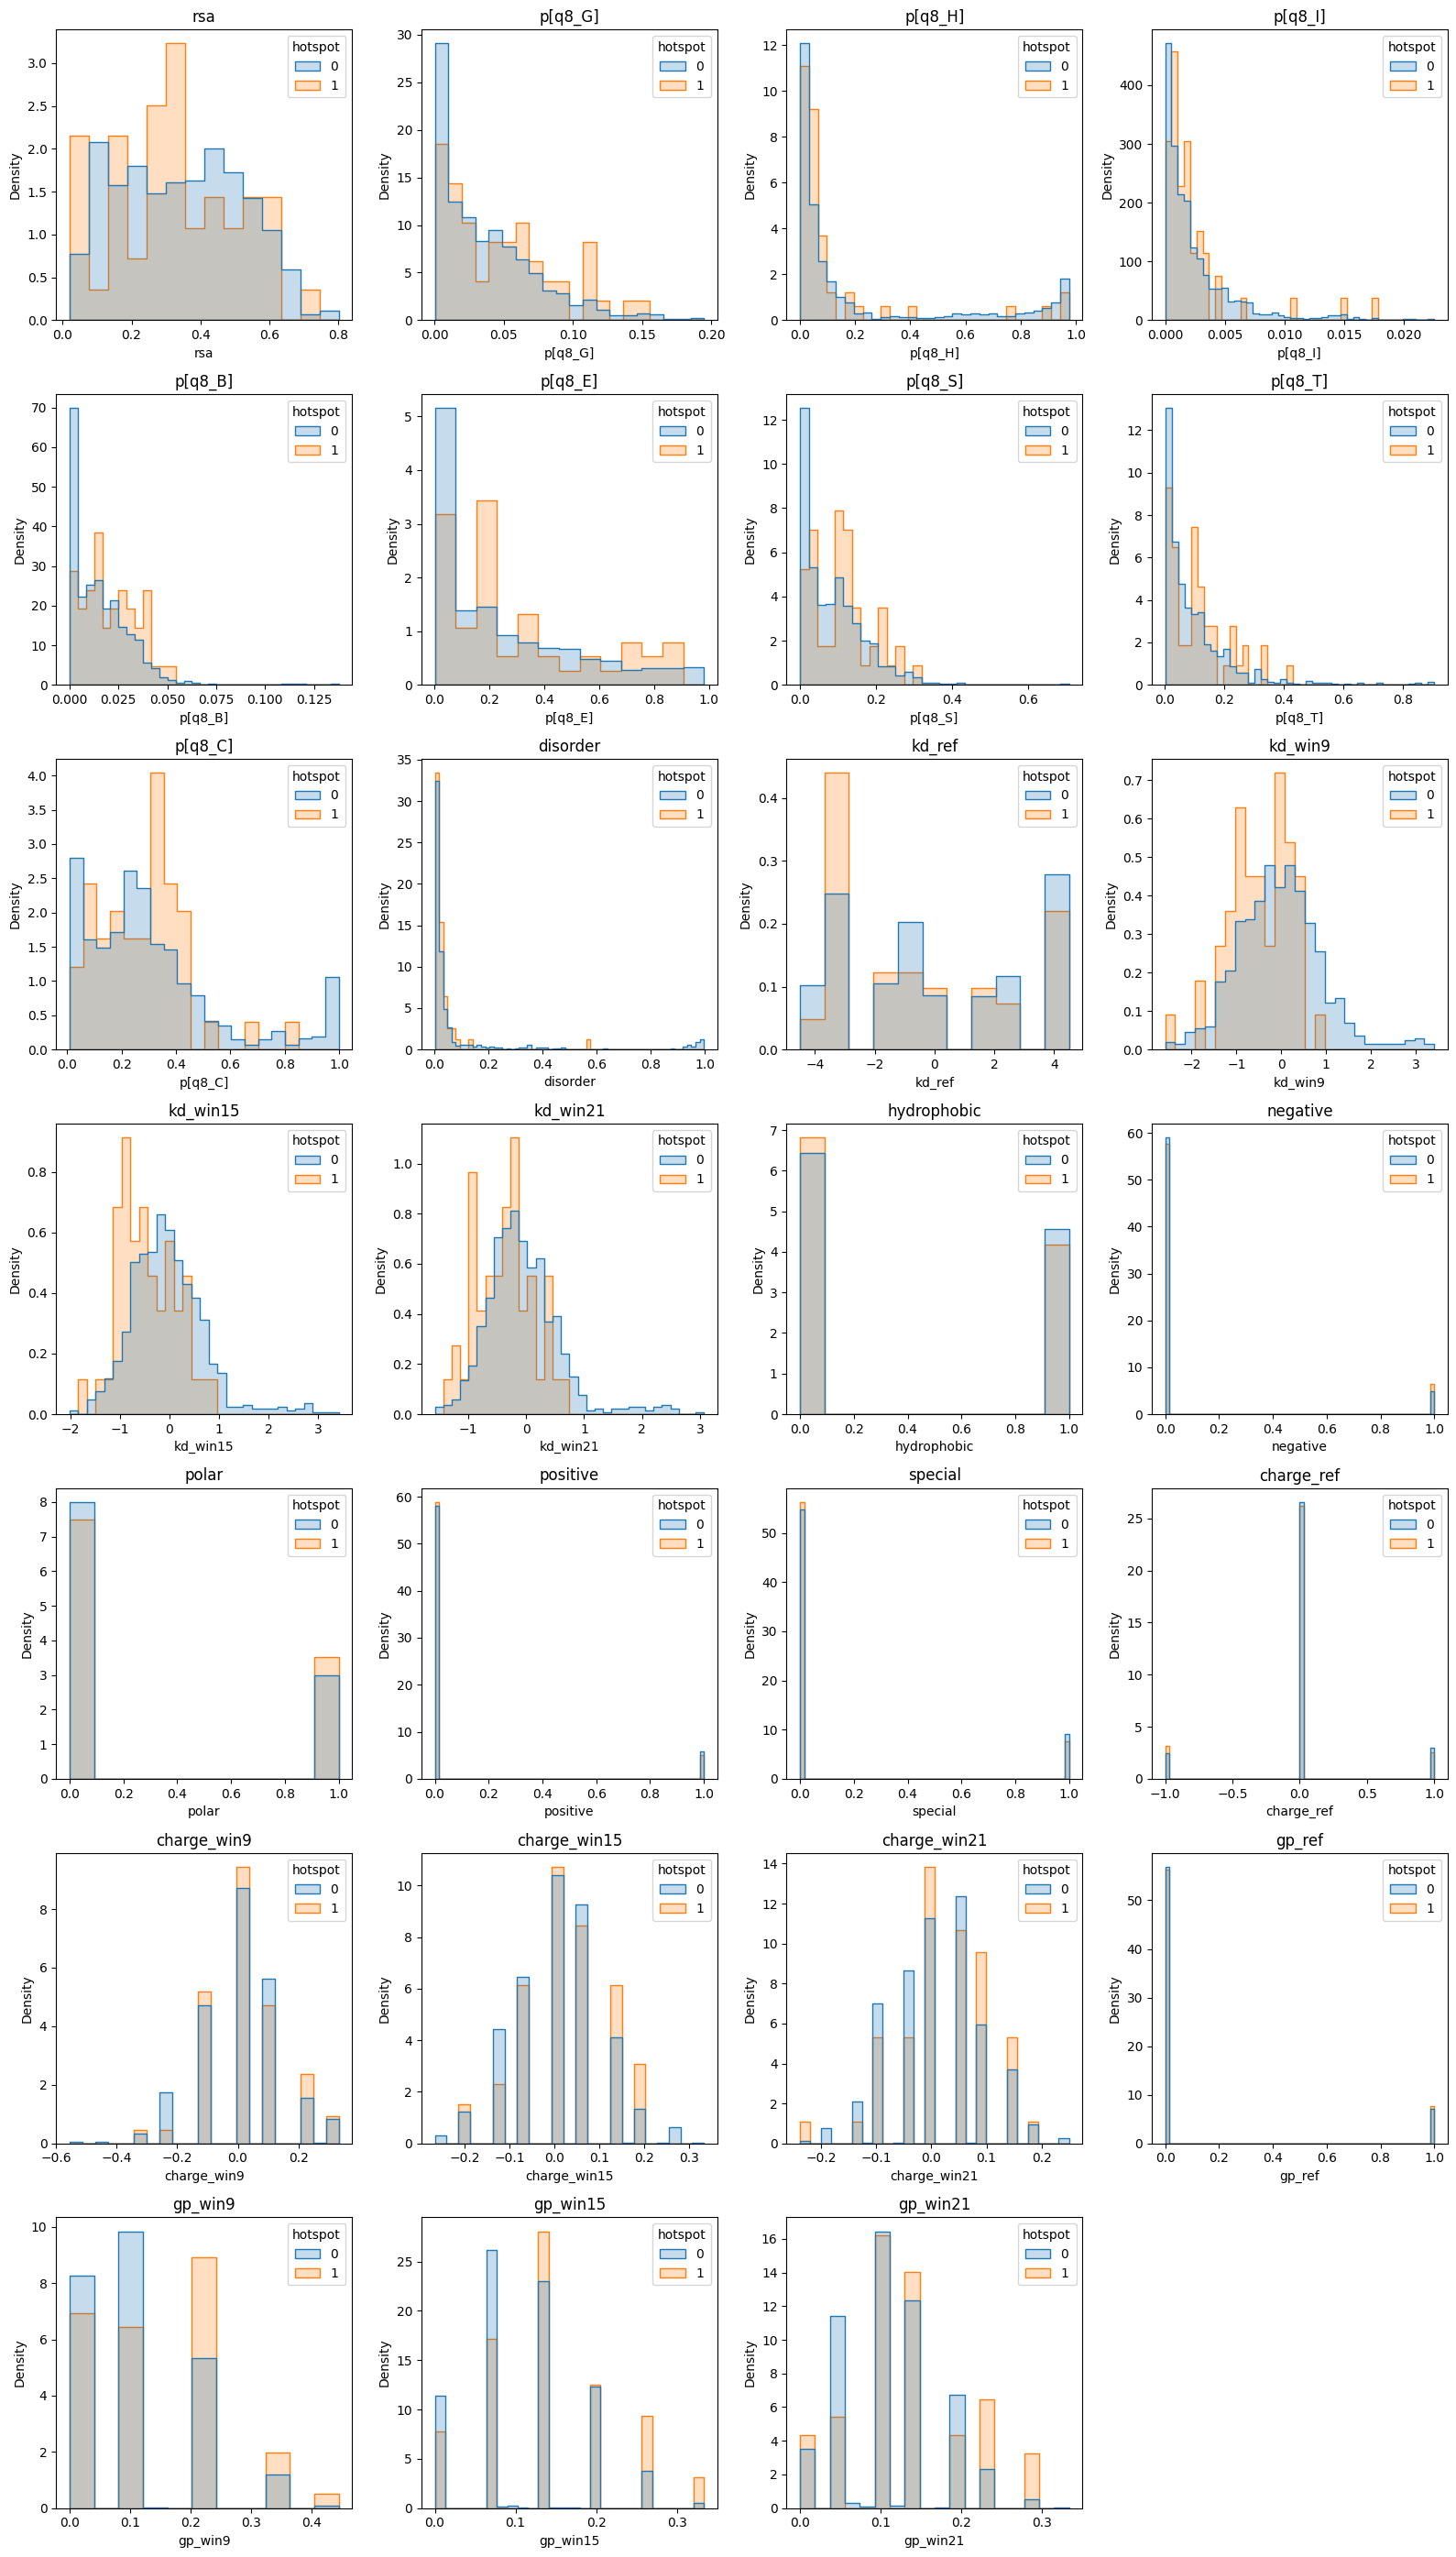

In [70]:
#Univariate Analysis: 

#attach label for plotting
train_df = X_train.copy()
train_df["hotspot"] = y_train.values

features = X_train.columns

n_cols = 4
n_rows = int(np.ceil(len(features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(
        data=train_df,
        x=col,
        hue="hotspot",
        element="step",
        stat="density",
        common_norm=False,
        ax=axes[i]
    )
    axes[i].set_title(col)

# Remove unused axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


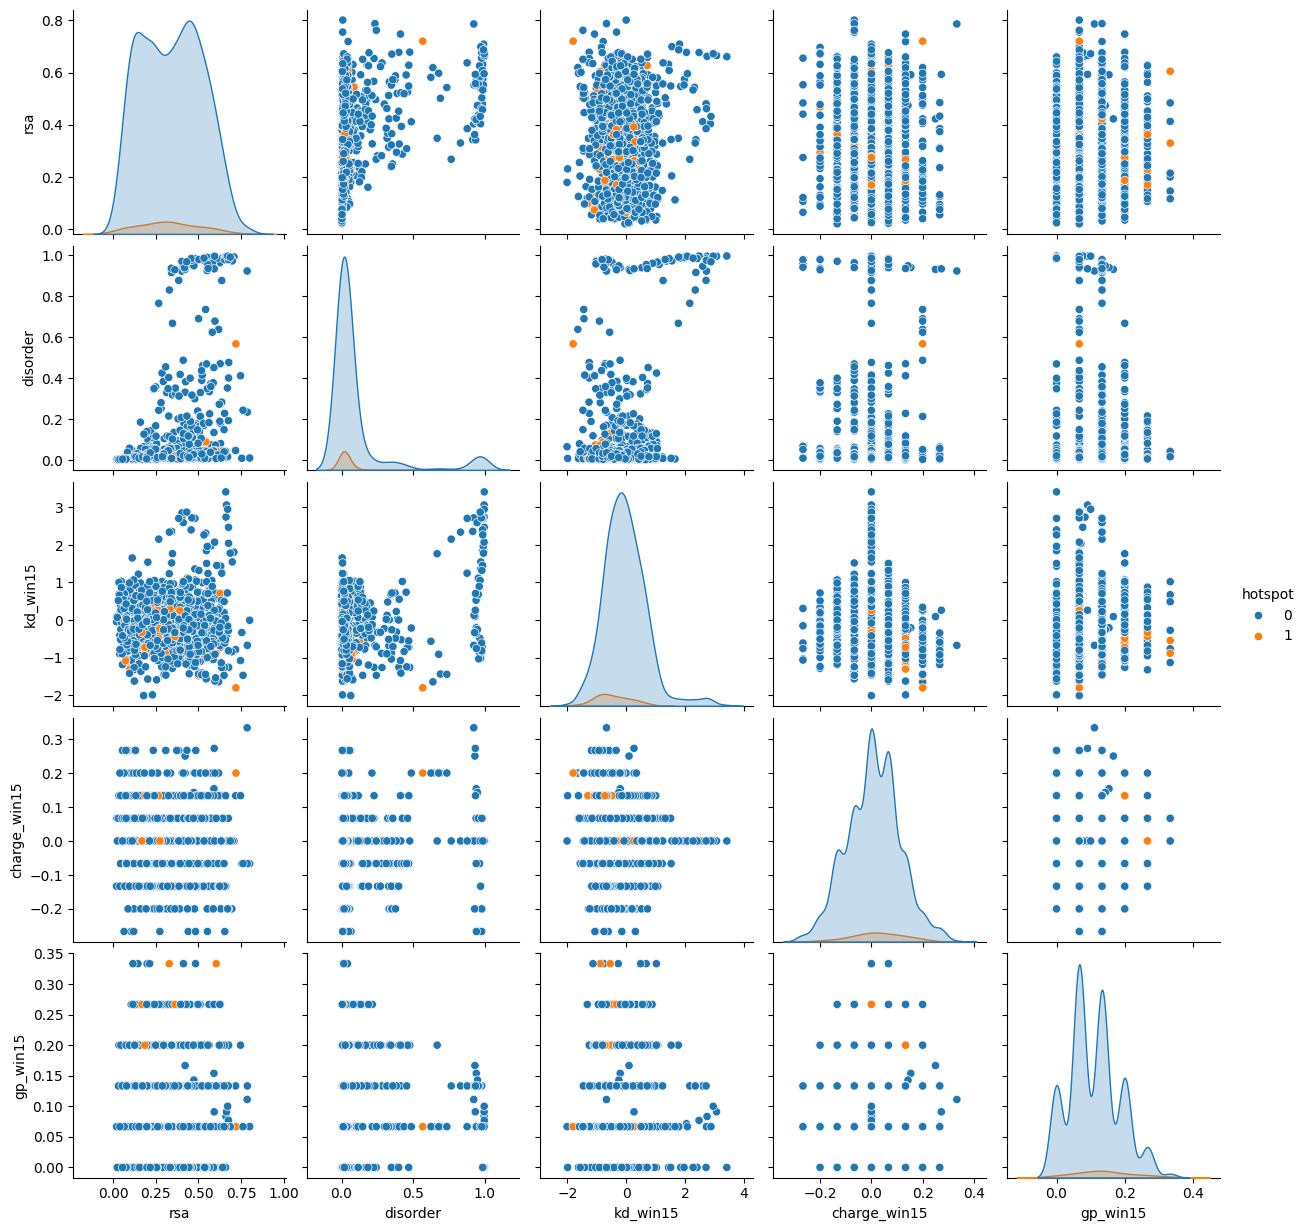

In [71]:
subset = train_df[["rsa", "disorder", "kd_win15", "charge_win15","gp_win15","hotspot"]]

sns.pairplot(subset, hue="hotspot", diag_kind="kde")
plt.show()

In [72]:
#Correlated Features

# combine X and y
train_df = X_train.copy()
train_df["hotspot"] = y_train

# compute correlations
corr = train_df.corr()["hotspot"].drop("hotspot")

corr.sort_values(key=abs, ascending=False)

kd_win15       -0.120091
kd_win21       -0.110438
kd_win9        -0.101212
gp_win15        0.089101
p[q8_B]         0.080150
gp_win9         0.075685
gp_win21        0.074381
p[q8_S]         0.067445
p[q8_G]         0.063634
disorder       -0.062665
p[q8_H]        -0.057301
kd_ref         -0.046480
p[q8_E]         0.046294
charge_win21    0.041370
charge_win15    0.038067
p[q8_C]        -0.025438
p[q8_T]         0.024522
polar           0.022878
charge_win9     0.022874
negative        0.018087
charge_ref     -0.018075
rsa            -0.017524
hydrophobic    -0.015038
special        -0.014590
p[q8_I]        -0.009703
positive       -0.008958
gp_ref          0.006510
Name: hotspot, dtype: float64

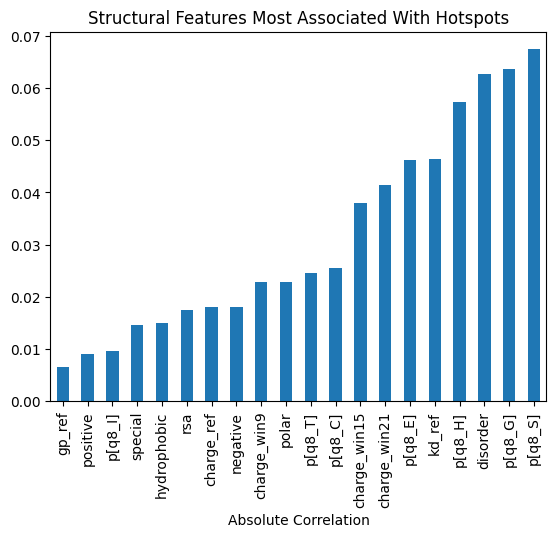

In [73]:
top_features = corr.abs().sort_values(ascending=True).head(20)

top_features.plot(kind="bar")
plt.title("Structural Features Most Associated With Hotspots")
plt.xlabel("Absolute Correlation")
plt.show()

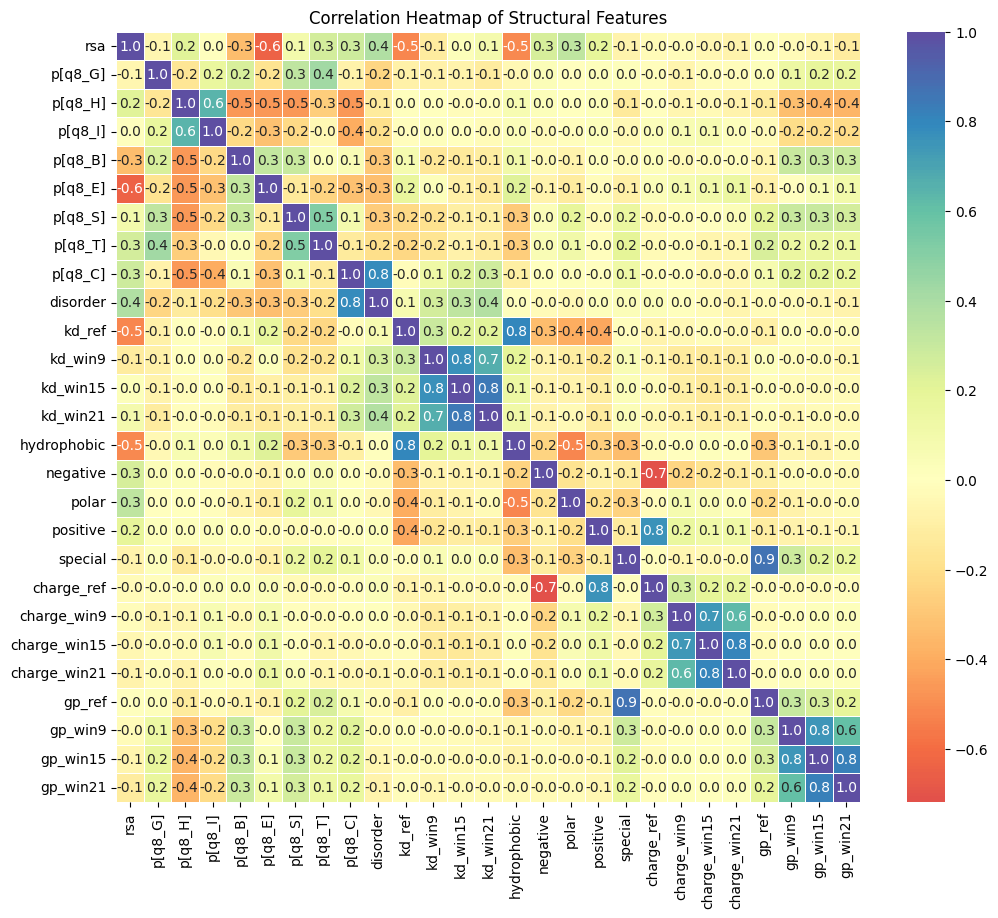

gp_ref        special         0.867038
special       gp_ref          0.867038
kd_win21      kd_win15        0.844279
kd_win15      kd_win21        0.844279
gp_win15      gp_win21        0.820443
gp_win21      gp_win15        0.820443
charge_win15  charge_win21    0.808971
charge_win21  charge_win15    0.808971
hydrophobic   kd_ref          0.797344
kd_ref        hydrophobic     0.797344
p[q8_C]       disorder        0.779202
disorder      p[q8_C]         0.779202
kd_win9       kd_win15        0.767707
kd_win15      kd_win9         0.767707
positive      charge_ref      0.759711
charge_ref    positive        0.759711
gp_win9       gp_win15        0.753781
gp_win15      gp_win9         0.753781
charge_win15  charge_win9     0.743976
charge_win9   charge_win15    0.743976
negative      charge_ref      0.717817
charge_ref    negative        0.717817
kd_win9       kd_win21        0.666400
kd_win21      kd_win9         0.666400
p[q8_I]       p[q8_H]         0.639071
p[q8_H]       p[q8_I]    

In [74]:
corr_matrix = X_train.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap="Spectral",
    annot = True,
    fmt=".1f",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Structural Features")
plt.show()

#correlations list

corr_pairs = corr_matrix.abs().unstack()
# remove self-correlations
corr_pairs = corr_pairs[corr_pairs < 1]
# sort descending
corr_pairs = corr_pairs.sort_values(ascending=False)

print(corr_pairs.head(29))

In [75]:
# function to plot PCA for windows = [9,15,21]

X_train = X_train.drop(columns=["negative", "positive", "special"])
X_test  = X_test.drop(columns=["negative", "positive", "special"])

X_train.columns

Index(['rsa', 'p[q8_G]', 'p[q8_H]', 'p[q8_I]', 'p[q8_B]', 'p[q8_E]', 'p[q8_S]',
       'p[q8_T]', 'p[q8_C]', 'disorder', 'kd_ref', 'kd_win9', 'kd_win15',
       'kd_win21', 'hydrophobic', 'polar', 'charge_ref', 'charge_win9',
       'charge_win15', 'charge_win21', 'gp_ref', 'gp_win9', 'gp_win15',
       'gp_win21'],
      dtype='str')

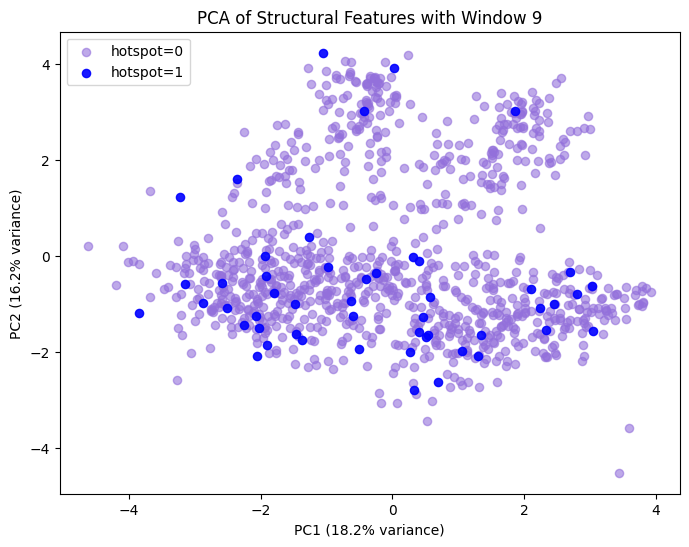

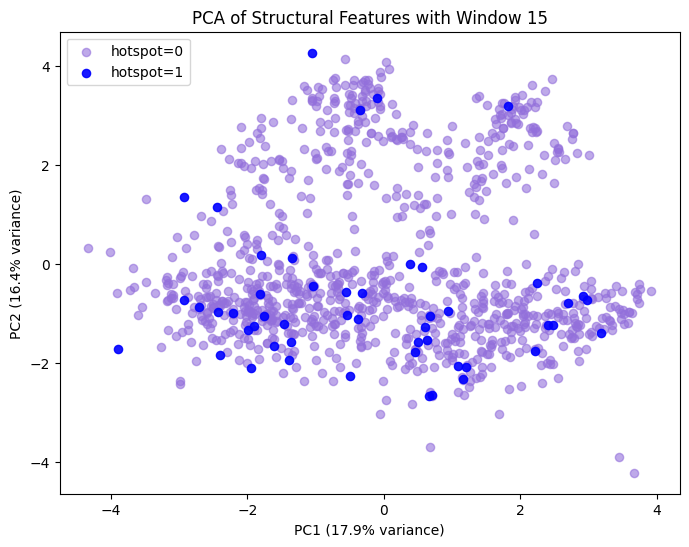

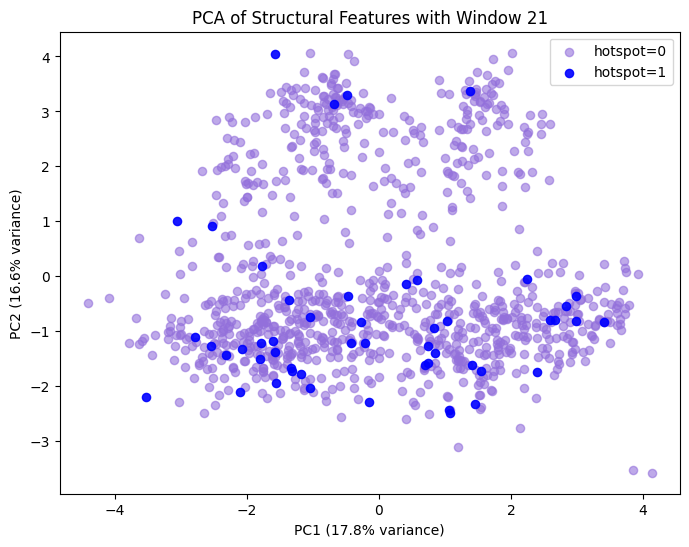

In [76]:
def pca_plots_win(X_train, y_train, W_size):
    #define which windows to use
    windows_used = [f"kd_win{W_size}", f"charge_win{W_size}",f"gp_win{W_size}"]
    all_window_cols = [
        "kd_win9", "kd_win15", "kd_win21",
        "charge_win9", "charge_win15", "charge_win21",
        "gp_win9", "gp_win15", "gp_win21"
    ]

    #keep all non-window columns + chosen windows_used
    cols_keep = [col for col in X_train.columns if col not in all_window_cols] + windows_used
    X_subset = X_train[cols_keep].copy()

    #Scale the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_subset)

    #PCA
    pca = PCA(n_components = 2)
    X_pca = pca.fit_transform(X_scaled)

    #put into a dataframe for plotting
    pca_df = pd.DataFrame({
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "hotspot": y_train.values
    })

    #Plot
    plt.figure(figsize=(8, 6))
    for label, color, alpha in [(0,"mediumpurple", 0.6), (1,"blue", 0.9)]:
        subset = pca_df[pca_df["hotspot"] == label]
        plt.scatter(
            subset["PC1"],
            subset["PC2"],
            label=f"hotspot={label}",
            alpha=alpha,
            s=35,
            color = color
        )

    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
    plt.title(f"PCA of Structural Features with Window {W_size}")
    plt.legend()
    plt.show()
    
    return pca_df, pca, cols_keep

pca9_df, pca9, cols9 = pca_plots_win(X_train, y_train, 9)
pca15_df, pca15, cols15 = pca_plots_win(X_train, y_train, 15)
pca21_df, pca21, cols21 = pca_plots_win(X_train, y_train, 21)

In [77]:
#UMAP plots 

#create scaled X-train and X-test

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


UMAP_red = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = UMAP_red.fit_transform(X_train_scaled)

C:\Users\bphul\miniconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


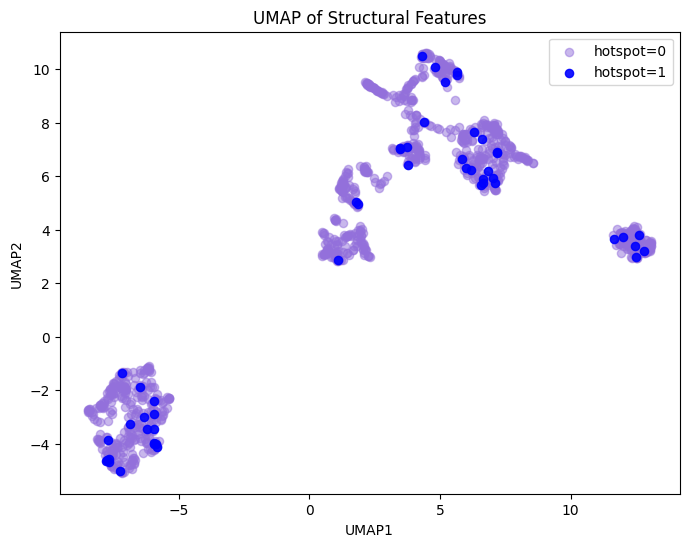

In [78]:
#plot

plt.figure(figsize=(8,6))

for label, color, alpha in [(0, "mediumpurple", 0.5), (1, "blue", 0.9)]:
    mask = (y_train == label)
    plt.scatter(
        X_umap[mask, 0],
        X_umap[mask, 1],
        label=f"hotspot={label}",
        alpha=alpha,
        s=35,
        color = color
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP of Structural Features")
plt.legend()
plt.show()

In [79]:
# Baseline Model: ELASTIC NET 

# ---------------------------------------------------
# 1. Create modeling dataset
# ---------------------------------------------------
model_df = finalseq_df2.copy()

# X = predictors only
X = model_df.drop(columns=["hotspot", "wuhan_resnum"])

# y = target
y = model_df["hotspot"]

# ---------------------------------------------------
# 2. Train/test split
# ---------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set class counts:")
print(y_train.value_counts())
print("\nTest set class counts:")
print(y_test.value_counts())

# ---------------------------------------------------
# 3. Build pipeline
#    Scaling happens inside CV -> avoids leakage
# ---------------------------------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        class_weight="balanced",
        max_iter=10000,
        random_state=42
    ))
])

# ---------------------------------------------------
# 4. Hyperparameter grid
# ---------------------------------------------------
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0]
}

# Notes:
# l1_ratio = 0   -> ridge-like
# l1_ratio = 1   -> lasso-like
# middle values  -> elastic net mix

# ---------------------------------------------------
# 5. Cross-validation setup
# ---------------------------------------------------
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ---------------------------------------------------
# 6. Grid search
#    scoring = "average_precision" is often better for imbalance
# ---------------------------------------------------
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="average_precision",   # PR-AUC
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid.fit(X_train, y_train)

# ---------------------------------------------------
# 7. Best CV results
# ---------------------------------------------------
print("\nBest hyperparameters:")
print(grid.best_params_)

print("\nBest CV average precision (PR-AUC):")
print(grid.best_score_)

best_model = grid.best_estimator_

# ---------------------------------------------------
# 8. Test set evaluation
# ---------------------------------------------------
y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred = best_model.predict(X_test)

test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)

print("\nTest ROC-AUC:", test_roc_auc)
print("Test PR-AUC:", test_pr_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, digits=3))


Training set class counts:
hotspot
0    968
1     50
Name: count, dtype: int64

Test set class counts:
hotspot
0    242
1     13
Name: count, dtype: int64
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best hyperparameters:
{'model__C': 0.01, 'model__l1_ratio': 0.0}

Best CV average precision (PR-AUC):
0.1167340972136193

Test ROC-AUC: 0.6112523839796566
Test PR-AUC: 0.07228001747216116

Confusion Matrix:
[[158  84]
 [  7   6]]

Classification Report:
              precision    recall  f1-score   support

           0      0.958     0.653     0.776       242
           1      0.067     0.462     0.117        13

    accuracy                          0.643       255
   macro avg      0.512     0.557     0.446       255
weighted avg      0.912     0.643     0.743       255



C:\Users\bphul\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


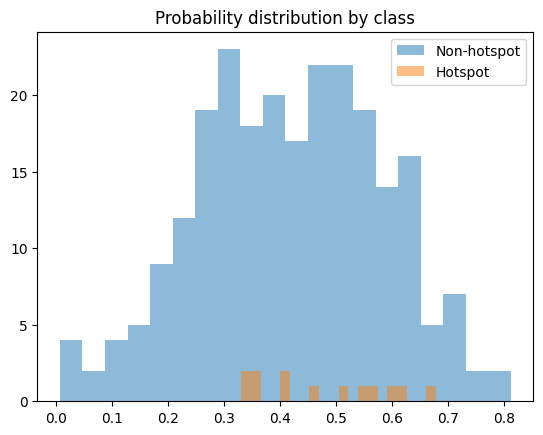

In [80]:
y_prob = grid.best_estimator_.predict_proba(X_test)[:, 1]

plt.hist(y_prob[y_test == 0], bins=20, alpha=0.5, label="Non-hotspot")
plt.hist(y_prob[y_test == 1], bins=20, alpha=0.5, label="Hotspot")
plt.legend()
plt.title("Probability distribution by class")
plt.show()

In [81]:
#-------------------------------------------
# Random Forest
#-------------------------------------------

rf = RandomForestClassifier(
    random_state = 42,
    class_weight = "balanced"
)

param_grid = {
    "n_estimators": [200,500],
    "max_depth": [None, 5,10],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,5],
    "max_features": ["sqrt","log2"]
}

#cross validate
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

#grid search
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="average_precision",   # PR-AUC
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid_rf.fit(X_train,y_train)

print("Best RF hyperparameters: ", grid_rf.best_params_)
print("Best CV average precision: ", grid_rf.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best RF hyperparameters:  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best CV average precision:  0.1592341075058826


In [82]:
#------------------------------------------
# Evaluate Metrics
#------------------------------------------

y_prob_enet = best_model.predict_proba(X_test)[:, 1]
y_pred_enet = (y_prob_enet >= 0.5).astype(int)

y_prob_rf = grid_rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= 0.5).astype(int)

def evaluate_model(y_true, y_prob, y_pred):
    return {
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    }

results_enet = evaluate_model(y_test, y_prob_enet, y_pred_enet)
results_rf = evaluate_model(y_test, y_prob_rf, y_pred_rf)

In [83]:
comparison = pd.DataFrame([results_enet, results_rf], index=["Elastic Net", "Random Forest"])
print(comparison)

                ROC_AUC    PR_AUC  Precision    Recall        F1
Elastic Net    0.611252  0.072280   0.066667  0.461538  0.116505
Random Forest  0.649714  0.073607   0.000000  0.000000  0.000000


In [84]:
# the default hotspot threshold may be too high for the models to actually pick up hotspot signal so i need to change the threshold. Maybe 0.1 is good 

t = [0.01,0.02,0.05,0.1]

for thresh in t: 
    y_pred_enet = (y_prob_enet >= thresh).astype(int)
    y_pred_rf = (y_prob_rf >= thresh).astype(int)
    
    print("Elastic Net: ",thresh)
    print(confusion_matrix(y_test, y_pred_enet))
    print(classification_report(y_test, y_pred_enet))

    print("Random Forest: ", thresh)
    print(confusion_matrix(y_test, y_pred_rf))
    print(classification_report(y_test, y_pred_rf))


Elastic Net:  0.01
[[  1 241]
 [  0  13]]
              precision    recall  f1-score   support

           0       1.00      0.00      0.01       242
           1       0.05      1.00      0.10        13

    accuracy                           0.05       255
   macro avg       0.53      0.50      0.05       255
weighted avg       0.95      0.05      0.01       255

Random Forest:  0.01
[[ 59 183]
 [  0  13]]
              precision    recall  f1-score   support

           0       1.00      0.24      0.39       242
           1       0.07      1.00      0.12        13

    accuracy                           0.28       255
   macro avg       0.53      0.62      0.26       255
weighted avg       0.95      0.28      0.38       255

Elastic Net:  0.02
[[  2 240]
 [  0  13]]
              precision    recall  f1-score   support

           0       1.00      0.01      0.02       242
           1       0.05      1.00      0.10        13

    accuracy                           0.06       255


# Stage 2: Mutation Classification

In [85]:
finalseq_df2.head(3)

,hotspot,wuhan_resnum,rsa,p[q8_G],p[q8_H],p[q8_I],p[q8_B],p[q8_E],p[q8_S],p[q8_T],...,positive,special,charge_ref,charge_win9,charge_win15,charge_win21,gp_ref,gp_win9,gp_win15,gp_win21
0,0,1.0,0.660813,0.000175,0.000576,0.000018,0.000184,0.000401,0.000930,0.000894,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.090909
50,0,2.0,0.682652,0.000101,0.000402,0.000006,0.000074,0.000237,0.000523,0.000628,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.111111,0.083333
100,0,3.0,0.672084,0.000074,0.000361,0.000003,0.000033,0.000152,0.000475,0.000497,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.100000,0.076923


In [86]:
# drop hotspot because we are re-creating new target features mutation and mut_prob
finalseq_df3 = finalseq_df2.copy()
finalseq_df3 = finalseq_df3.drop(columns = 'hotspot')

In [87]:
#write to csv
finalseq_df3.to_csv("finalseq_df3.csv",index = False)

In [88]:
# filter to valid reference positions (no insertions)
seq6_df2 = seq6_df.copy()
seq6_df2 = seq6_df2[seq6_df2["wuhan_residue"] != "-"].copy()

agg = (
    seq6_df2.groupby("wuhan_resnum")
    .agg(
        valid_n=("mutation", lambda x: x.notna().sum()),
        stable_count=("mutation", lambda x: (x == 0).sum()),
        sub_count=("mutation", lambda x: (x == 1).sum()),
        del_count=("mutation", lambda x: (x == 2).sum()),
    )
    .reset_index()
)

In [89]:
#define mutation class
def assign_class(row):
    if row["sub_count"] == 0 and row["del_count"] == 0:
        return 0
    elif row["sub_count"] >= row["del_count"]:
        return 1
    else:
        return 2

agg["mutation_class"] = agg.apply(assign_class, axis=1)

In [90]:
#modeling daraframe 
model_df = finalseq_df3.merge(agg, on="wuhan_resnum", how="inner")

In [91]:
model_df.head(4)

,wuhan_resnum,rsa,p[q8_G],p[q8_H],p[q8_I],p[q8_B],p[q8_E],p[q8_S],p[q8_T],p[q8_C],...,charge_win21,gp_ref,gp_win9,gp_win15,gp_win21,valid_n,stable_count,sub_count,del_count,mutation_class
0,1.0,0.660813,0.000175,0.000576,0.000018,0.000184,0.000401,0.000930,0.000894,0.996821,...,0.0,0.0,0.0,0.000000,0.090909,50,50,0,0,0
1,2.0,0.682652,0.000101,0.000402,0.000006,0.000074,0.000237,0.000523,0.000628,0.998030,...,0.0,0.0,0.0,0.111111,0.083333,49,49,0,0,0
2,3.0,0.672084,0.000074,0.000361,0.000003,0.000033,0.000152,0.000475,0.000497,0.998407,...,0.0,0.0,0.0,0.100000,0.076923,50,50,0,0,0
3,4.0,0.665079,0.000071,0.000366,0.000002,0.000030,0.000120,0.000520,0.000498,0.998392,...,0.0,0.0,0.0,0.090909,0.071429,50,50,0,0,0


In [92]:
#add in probability for each mutation
model_df["p_stable"] = model_df["stable_count"] / model_df["valid_n"]
model_df["p_sub"] = model_df["sub_count"] / model_df["valid_n"]
model_df["p_del"] = model_df["del_count"] / model_df["valid_n"]

In [93]:
model_df.head(25)

,wuhan_resnum,rsa,p[q8_G],p[q8_H],p[q8_I],p[q8_B],p[q8_E],p[q8_S],p[q8_T],p[q8_C],...,gp_win15,gp_win21,valid_n,stable_count,sub_count,del_count,mutation_class,p_stable,p_sub,p_del
0,1.0,0.660813,0.000175,0.000576,0.000018,0.000184,0.000401,0.000930,0.000894,0.996821,...,0.000000,0.090909,50,50,0,0,0,1.00,0.00,0.00
1,2.0,0.682652,0.000101,0.000402,0.000006,0.000074,0.000237,0.000523,0.000628,0.998030,...,0.111111,0.083333,49,49,0,0,0,1.00,0.00,0.00
2,3.0,0.672084,0.000074,0.000361,0.000003,0.000033,0.000152,0.000475,0.000497,0.998407,...,0.100000,0.076923,50,50,0,0,0,1.00,0.00,0.00
3,4.0,0.665079,0.000071,0.000366,0.000002,0.000030,0.000120,0.000520,0.000498,0.998392,...,0.090909,0.071429,50,50,0,0,0,1.00,0.00,0.00
4,5.0,0.662311,0.000074,0.000376,0.000003,0.000034,0.000125,0.000618,0.000520,0.998250,...,0.083333,0.066667,50,49,1,0,1,0.98,0.02,0.00
5,6.0,0.676829,0.000046,0.000218,0.000002,0.000030,0.000112,0.000588,0.000348,0.998657,...,0.076923,0.062500,50,50,0,0,0,1.00,0.00,0.00
6,7.0,0.677453,0.000039,0.000180,0.000002,0.000037,0.000106,0.000811,0.000357,0.998467,...,0.071429,0.058824,50,50,0,0,0,1.00,0.00,0.00
7,8.0,0.595599,0.000047,0.000152,0.000002,0.000057,0.000139,0.001049,0.000323,0.998232,...,0.066667,0.055556,50,50,0,0,0,1.00,0.00,0.00
8,9.0,0.646235,0.000079,0.000238,0.000002,0.000036,0.000085,0.000553,0.000579,0.998429,...,0.066667,0.052632,50,50,0,0,0,1.00,0.00,0.00
9,10.0,0.708962,0.000164,0.000587,0.000004,0.000048,0.000113,0.001083,0.001370,0.996631,...,0.066667,0.050000,50,50,0,0,0,1.00,0.00,0.00


In [94]:
# re-run UMAPs to visualize the clusters

feature_cols = ['rsa', 'disorder',
                'p[q8_G]','p[q8_H]','p[q8_I]','p[q8_B]','p[q8_E]','p[q8_S]','p[q8_T]','p[q8_C]',
                'kd_ref','kd_win9', 'kd_win15','kd_win21',
                'hydrophobic', 'negative','polar','positive', 'special', 
                'charge_ref','charge_win9','charge_win15','charge_win21',
                'gp_ref','gp_win9','gp_win15','gp_win21'
               ]
output_col = ['p_stable','p_sub','p_del']

X_mut = model_df[feature_cols]
y_prob = model_df[output_col]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_mut)

umap_model = umap.UMAP(
    n_neighbors = 15,
    min_dist = 0.1,
    n_components = 2,
    random_state = 429,
)

x_umap = umap_model.fit_transform(X_scaled)

C:\Users\bphul\miniconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [95]:
# y_class = y_prob.idxmax(axis = 1) #'p_stable', 'p_sub','p_del'
# y_class.value_counts()

# # Check if p_del ever exceeds the others
# ((y_prob['p_del'] > y_prob['p_sub']) & 
#  (y_prob['p_del'] > y_prob['p_stable'])).sum()

# y_prob['p_del'].describe()

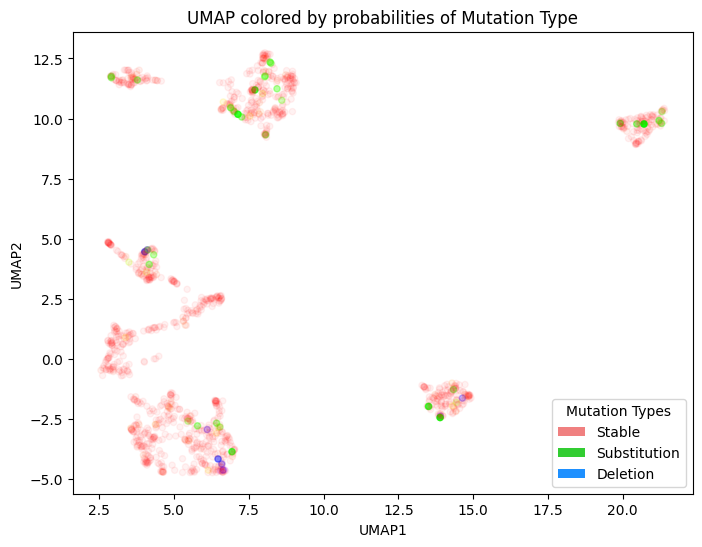

In [96]:
# plot and color by mutation type
y_class =y_prob[['p_stable','p_sub','p_del']].values  #'p_stable', 'p_sub','p_del'

colors = ['p_stable','p_sub','p_del']

p_stable = y_prob['p_stable'].values
p_sub = y_prob['p_sub'].values
p_del = y_prob['p_del'].values

#colors for probabilities
R = p_stable * 0.25                # red-ish for stable (0.25 for transparency)
G = p_sub * 2.0                    # green = substitution (2 for opacity)
B = p_del * 3.0                    # blue = deletion (3 for opacity)

# Stack RGB
colors = np.stack([R, G, B], axis=1)

# Normalize (important so values stay valid)
colors = colors / colors.max(axis=1, keepdims=True)

plt.figure(figsize = (8,6))
plt.scatter(
    x=x_umap[:,0],
    y=x_umap[:,1],
    c = colors,
    s = 20,
    alpha = 0.05 + 0.9 * (p_sub + p_del)
)

legend_elements = [
    Patch(facecolor='lightcoral', label='Stable'),
    Patch(facecolor='limegreen', label='Substitution'),
    Patch(facecolor='dodgerblue', label='Deletion')
]

plt.title("UMAP colored by probabilities of Mutation Type")
plt.legend(handles=legend_elements, title="Mutation Types")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.show()

In [97]:
# Baseline Model: XGBoost 

feature_cols = ['rsa', 'disorder',
                'p[q8_G]','p[q8_H]','p[q8_I]','p[q8_B]','p[q8_E]','p[q8_S]','p[q8_T]','p[q8_C]',
                'kd_ref','kd_win9', 'kd_win15','kd_win21',
                'hydrophobic', 'negative','polar','positive', 'special', 
                'charge_ref','charge_win9','charge_win15','charge_win21',
                'gp_ref','gp_win9','gp_win15','gp_win21'
               ]
target_col = ['p_stable','p_sub','p_del']


X_xgmodel = model_df[feature_cols].copy()
X_xgmodel.columns = [
    col.replace('[', '_').replace(']', '') for col in X_xgmodel.columns
]
y_xgmodel = model_df[target_col].copy()


#split data into train and test

X_train,X_test,y_train,y_test = train_test_split(
    X_xgmodel,
    y_xgmodel,
    test_size = 0.2,
    random_state = 42
)

# XGBoost Model

# Specify hyperparameters
hyperparam_grid = {
    "n_estimators": [5,10,25],  # Total number of trees in ensemble
    "max_depth": [3, 5],     # Max tree depth
    "learning_rate": [0.05, 0.1, 0.5]   # Different learning rates
}

# Iterate through all hyperparameter value configurations
for hyperparams in ParameterGrid(hyperparam_grid):

        preds = []
        results = []

        # Define XGBoost model in pipeline
        xgboost_model = XGBRegressor(
            objective = "reg:squarederror",
            random_state = 42,
            **hyperparams
        )

        # Fit model to training data, evaluate on holdout (testing) data
        xgboost_model.fit(X_train, y_train)
        y_pred = xgboost_model.predict(X_test)
        preds.append(y_pred)

        # clean predictions
        y_pred = np.clip(y_pred, 0, None)

        row_sums = y_pred.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        y_pred = y_pred / row_sums

         # metrics
        mae_stable = mean_absolute_error(y_test['p_stable'], y_pred[:, 0])
        mae_sub    = mean_absolute_error(y_test['p_sub'], y_pred[:, 1])
        mae_del    = mean_absolute_error(y_test['p_del'], y_pred[:, 2])

        rmse = np.sqrt(mean_squared_error(y_test.values, y_pred))
        print(f"\nParams: {hyperparams}")
        print(f"p_stable MAE: {mae_stable:.4f}")
        print(f"p_sub MAE: {mae_sub:.4f}")
        print(f"p_del MAE: {mae_del:.4f}")
        print(f"Overall RMSE: {rmse:.4f}")

        # save results
        results.append({
        **hyperparams,
        "mae_stable": mae_stable,
        "mae_sub": mae_sub,
        "mae_del": mae_del,
        "rmse": rmse
        })
         


Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 5}
p_stable MAE: 0.0301
p_sub MAE: 0.0274
p_del MAE: 0.0038
Overall RMSE: 0.0754

Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 10}
p_stable MAE: 0.0299
p_sub MAE: 0.0274
p_del MAE: 0.0038
Overall RMSE: 0.0755

Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 25}
p_stable MAE: 0.0299
p_sub MAE: 0.0276
p_del MAE: 0.0039
Overall RMSE: 0.0760

Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 5}
p_stable MAE: 0.0304
p_sub MAE: 0.0278
p_del MAE: 0.0038
Overall RMSE: 0.0754

Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 10}
p_stable MAE: 0.0307
p_sub MAE: 0.0284
p_del MAE: 0.0038
Overall RMSE: 0.0761

Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 25}
p_stable MAE: 0.0310
p_sub MAE: 0.0290
p_del MAE: 0.0037
Overall RMSE: 0.0780

Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 5}
p_stable MAE: 0.0300
p_sub MAE: 0.0274
p_del MAE: 0.0

In [98]:
y_pred_class = np.argmax(y_pred, axis=1)
y_true_class = np.argmax(y_test.values, axis=1)

for i in range(200):
    print(f"Actual: {y_true_class[i]} | Predicted: {y_pred_class[i]}")

Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0


In [99]:
# XGBoost for 15-position window to see if it learns anything new

feature_cols = ['rsa', 'disorder',
                'p[q8_G]','p[q8_H]','p[q8_I]','p[q8_B]','p[q8_E]','p[q8_S]','p[q8_T]','p[q8_C]',
                'kd_ref','kd_win9', 'kd_win15','kd_win21',
                'hydrophobic', 'negative','polar','positive', 'special', 
                'charge_ref','charge_win9','charge_win15','charge_win21',
                'gp_ref','gp_win9','gp_win15','gp_win21'
               ]
target_col = ['p_stable','p_sub','p_del']

#create window 

window_size = 15
center = window_size // 2   # 7

window_rows = []

for i in range(center,len(model_df) - center):
    row_dict={}

    for offset in range(-center, center + 1):  # -7,-6,-5,...,+5,+6,+7
        for col in feature_cols:
            if offset < 0:
                new_col = f"{col}_m{abs(offset)}"
            elif offset > 0:
                new_col = f"{col}_p{offset}"
            else:
                new_col = f"{col}_0"
                
            row_dict[new_col] = model_df.iloc[i+offset][col]

    for col in target_col:
        row_dict[col] = model_df.iloc[i][col]

    window_rows.append(row_dict)

window_df = pd.DataFrame(window_rows)


        
X_xgwindow = window_df.drop(columns=target_col).copy()
X_xgwindow.columns = [
    col.replace('[', '_').replace(']', '') for col in X_xgwindow.columns
]
y_xgwindow = window_df[target_col].copy()

#split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_xgwindow,
    y_xgwindow,
    test_size=0.2,
    random_state=42
)

print(window_df.shape)
print(X_xgwindow.shape)
print(y_xgwindow.shape)

# XGBoost Model

# Specify hyperparameters
hyperparam_grid = {
    "n_estimators": [5,10,25],  # Total number of trees in ensemble
    "max_depth": [3, 5],     # Max tree depth
    "learning_rate": [0.05, 0.1, 0.5]   # Different learning rates
}

# Iterate through all hyperparameter value configurations
for hyperparams in ParameterGrid(hyperparam_grid):

        # Define XGBoost model in pipeline
        xgboost_model = XGBRegressor(
            objective = "reg:squarederror",
            random_state = 42,
            **hyperparams
        )

        # Fit model to training data, evaluate on holdout (testing) data
        xgboost_model.fit(X_train, y_train)
        y_pred = xgboost_model.predict(X_test)

        # clean predictions
        y_pred = np.clip(y_pred, 0, None)

        row_sums = y_pred.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        y_pred = y_pred / row_sums

         # metrics
        mae_stable = mean_absolute_error(y_test['p_stable'], y_pred[:, 0])
        mae_sub    = mean_absolute_error(y_test['p_sub'], y_pred[:, 1])
        mae_del    = mean_absolute_error(y_test['p_del'], y_pred[:, 2])

        rmse = np.sqrt(mean_squared_error(y_test.values, y_pred))
        print(f"\nParams: {hyperparams}")
        print(f"p_stable MAE: {mae_stable:.4f}")
        print(f"p_sub MAE: {mae_sub:.4f}")
        print(f"p_del MAE: {mae_del:.4f}")
        print(f"Overall RMSE: {rmse:.4f}")

(1259, 408)
(1259, 405)
(1259, 3)

Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 5}
p_stable MAE: 0.0265
p_sub MAE: 0.0242
p_del MAE: 0.0029
Overall RMSE: 0.0458

Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 10}
p_stable MAE: 0.0259
p_sub MAE: 0.0240
p_del MAE: 0.0025
Overall RMSE: 0.0456

Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 25}
p_stable MAE: 0.0255
p_sub MAE: 0.0241
p_del MAE: 0.0020
Overall RMSE: 0.0484

Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 5}
p_stable MAE: 0.0263
p_sub MAE: 0.0240
p_del MAE: 0.0028
Overall RMSE: 0.0460

Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 10}
p_stable MAE: 0.0255
p_sub MAE: 0.0236
p_del MAE: 0.0023
Overall RMSE: 0.0460

Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 25}
p_stable MAE: 0.0254
p_sub MAE: 0.0240
p_del MAE: 0.0017
Overall RMSE: 0.0504

Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 5}
p_stable MAE: 0.025

In [100]:
y_pred_class = np.argmax(y_pred, axis=1)
y_true_class = np.argmax(y_test.values, axis=1)

df_compare = pd.DataFrame({
    "actual_stable": y_test['p_stable'].values,
    "actual_sub": y_test['p_sub'].values,
    "actual_del": y_test['p_del'].values,

    "pred_stable": y_pred[:, 0],
    "pred_sub": y_pred[:, 1],
    "pred_del": y_pred[:, 2],

    "actual_class": y_true_class,
    "pred_class": y_pred_class
})

df_compare.head(100)
df_compare.to_csv("df_compare.csv")

In [101]:
#CNN on 15 window since local neighborhoods are important 


feature_cols = ['rsa', 'disorder',
                'p[q8_G]','p[q8_H]','p[q8_I]','p[q8_B]','p[q8_E]','p[q8_S]','p[q8_T]','p[q8_C]',
                'kd_ref','kd_win9', 'kd_win15','kd_win21',
                'hydrophobic', 'negative','polar','positive', 'special', 
                'charge_ref','charge_win9','charge_win15','charge_win21',
                'gp_ref','gp_win9','gp_win15','gp_win21'
               ]
target_col = ['p_stable','p_sub','p_del']

#create window for CNN
window_size = 7
center = window_size // 2   

x_windows = []
y_windows = []

for i in range(center,len(model_df) - center):
    window = model_df.iloc[i-center: i + center + 1][feature_cols].copy()
    window.columns =[
        col.replace('[', '_').replace(']', '') for col in window.columns
    ]
    
    x_windows.append(window.values)
    y_windows.append(model_df.iloc[i][target_col].values)

X_cnnmodel = np.array(x_windows)
y_cnnmodel = np.array(y_windows)


print("X shape:", X_cnnmodel.shape)   # should be (n_samples, 15, 27)
print("y shape:", y_cnnmodel.shape)   # should be (n_samples, 3)

#split into train and test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_cnnmodel,
    y_cnnmodel,
    test_size=0.20,
    random_state=429
)
y_train = np.argmax(y_train, axis=1)
y_temp = np.argmax(y_temp, axis=1)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=429
)

print(X_train.shape, X_val.shape, X_test.shape)


#need to scale features
scaler = StandardScaler()

X_train_flat = X_train.reshape(-1,X_train.shape[-1]) #(1259*15,27) treats every position in every window as a separate row
X_val_flat   = X_val.reshape(-1, X_val.shape[-1]) #(126*15,27)
X_test_flat  = X_test.reshape(-1, X_test.shape[-1]) #(126*15,27)

#scale the features
X_train = scaler.fit_transform(X_train_flat).reshape(X_train.shape) 
X_val   = scaler.transform(X_val_flat).reshape(X_val.shape)
X_test  = scaler.transform(X_test_flat).reshape(X_test.shape)


X shape: (1267, 7, 27)
y shape: (1267, 3)
(1013, 7, 27) (127, 7, 27) (127, 7, 27)


In [102]:
# Define the CNN (you got this Korie T.T)

tf.keras.backend.clear_session() # clear any previous sessions

cnn_model = keras.Sequential([
    layers.Input(shape = (15,27)),

    layers.Conv1D(
        filters = 27,
        kernel_size = 3,
        activation = 'relu',
        padding = 'same'
    ),

    layers.Conv1D(
        filters = 54,
        kernel_size = 3,
        activation = 'relu',
        padding = 'same'
    ),

    layers.Conv1D(
        filters = 108,
        kernel_size = 3,
        activation = 'relu',
        padding = 'same'
    ),

    layers.GlobalMaxPooling1D(),

    layers.Dense(54, activation = 'relu'),
    layers.Dropout(0.2),

    layers.Dense(27, activation = 'relu'),
    layers.Dropout(0.2),

    layers.Dense(3, activation = 'softmax')

    
])

In [103]:
# compile the CNN

cnn_model.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mae']
)

In [104]:
history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32
)

Epoch 1/30


InvalidArgumentError: Graph execution error:

Detected at node gradient_tape/compile_loss/mse/sub/BroadcastGradientArgs defined at (most recent call last):
  File "C:\Users\bphul\miniconda3\Lib\runpy.py", line 198, in _run_module_as_main

  File "C:\Users\bphul\miniconda3\Lib\runpy.py", line 88, in _run_code

  File "C:\Users\bphul\miniconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "C:\Users\bphul\miniconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "C:\Users\bphul\miniconda3\Lib\site-packages\ipykernel\kernelapp.py", line 758, in start

  File "C:\Users\bphul\miniconda3\Lib\site-packages\tornado\platform\asyncio.py", line 211, in start

  File "C:\Users\bphul\miniconda3\Lib\asyncio\base_events.py", line 683, in run_forever

  File "C:\Users\bphul\miniconda3\Lib\asyncio\base_events.py", line 2050, in _run_once

  File "C:\Users\bphul\miniconda3\Lib\asyncio\events.py", line 89, in _run

  File "C:\Users\bphul

In [ ]:
# CNN Model 2 smaller model 

tf.keras.backend.clear_session() # clear any previous sessions

cnn_model2 = keras.Sequential([
    layers.Input(shape = (15,27)),

    layers.Conv1D(
        filters = 27,
        kernel_size = 3,
        activation = 'relu',
        padding = 'same'
    ),

    layers.Conv1D(
        filters = 54,
        kernel_size = 3,
        activation = 'relu',
        padding = 'same'
    ),

    layers.GlobalMaxPooling1D(),

    layers.Dense(27, activation = 'relu'),
    layers.Dropout(0.2),

    layers.Dense(3, activation = 'softmax')
   
])

In [ ]:
# compile CNN model 2

cnn_model2.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mae']
)

In [ ]:
history = cnn_model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32
)

In [ ]:
# CNN Model 3 smaller model 

tf.keras.backend.clear_session() # clear any previous sessions

cnn_model3 = keras.Sequential([
    layers.Input(shape = (15,27)),

    layers.Conv1D(
        filters = 15,
        kernel_size = 3,
        activation = 'relu',
        padding = 'same'
    ),

    layers.Conv1D(
        filters = 30,
        kernel_size = 3,
        activation = 'relu',
        padding = 'same'
    ),

    layers.Conv1D(
        filters = 60,
        kernel_size = 3,
        activation = 'relu',
        padding = 'same'
    ),

    layers.GlobalMaxPooling1D(),

    layers.Dense(30, activation = 'relu'),
    layers.Dropout(0.2),

    layers.Dense(15, activation = 'relu'),
    layers.Dropout(0.2),

    layers.Dense(3, activation = 'softmax')
   
])

In [ ]:
# compile CNN model 2

cnn_model3.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mae']
)

In [ ]:
history = cnn_model3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32
)

In [ ]:
# evaluation of CNN model 2 and 3


y_pred2 = cnn_model2.predict(X_test)

mae_stable2 = mean_absolute_error(y_test[:, 0], y_pred2[:, 0])
mae_sub2    = mean_absolute_error(y_test[:, 1], y_pred2[:, 1])
mae_del2    = mean_absolute_error(y_test[:, 2], y_pred2[:, 2])
rmse2       = np.sqrt(mean_squared_error(y_test, y_pred2))

print(f"p_stable MAE: {mae_stable2:.4f}")
print(f"p_sub MAE: {mae_sub2:.4f}")
print(f"p_del MAE: {mae_del2:.4f}")
print(f"Overall RMSE: {rmse2:.4f}")




y_pred3 = cnn_model3.predict(X_test)

mae_stable3 = mean_absolute_error(y_test[:, 0], y_pred3[:, 0])
mae_sub3    = mean_absolute_error(y_test[:, 1], y_pred3[:, 1])
mae_del3    = mean_absolute_error(y_test[:, 2], y_pred3[:, 2])
rmse3       = np.sqrt(mean_squared_error(y_test, y_pred3))

print(f"p_stable MAE: {mae_stable3:.4f}")
print(f"p_sub MAE: {mae_sub3:.4f}")
print(f"p_del MAE: {mae_del3:.4f}")
print(f"Overall RMSE: {rmse3:.4f}")

# Mapping to a 3D Structure

In [ ]:
# CNN Model 4 smaller model 

tf.keras.backend.clear_session() # clear any previous sessions

cnn_model4 = keras.Sequential([
    layers.Input(shape = (7, 27)),

    layers.Conv1D(
        filters = 7,
        kernel_size = 3,
        activation = 'relu',
        padding = 'same'
    ),

    layers.Conv1D(
        filters = 21,
        kernel_size = 3,
        activation = 'relu',
        padding = 'same'
    ),
    
    layers.Conv1D(
        filters = 45,
        kernel_size = 3,
        activation = 'relu',
        padding = 'same'
    ),

    layers.GlobalMaxPooling1D(),

    layers.Dense(20, activation = 'relu'),

    layers.Dense(10, activation = 'relu'),

    layers.Dense(3, activation = 'softmax')
   
])

In [ ]:
# compile CNN model 4
from tensorflow.keras.optimizers import Adam

cnn_model4.compile(
    optimizer = Adam(learning_rate = 0.0001),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy'],
  
)

In [ ]:
class_weight = {
    0: 0.25,   # majority class
    1: 100.0,   # minority class
    2: 100.0    # smallest class
}
history = cnn_model4.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    class_weight = class_weight
)

In [ ]:
from tensorflow.keras.utils import to_categorical

y_pred_probs = cnn_model4.predict(X_test)

y_test_probs = to_categorical(y_test, num_classes=3)

df_compare_cnn = pd.DataFrame({
    "actual_p_stable": y_test_probs[:, 0],
    "actual_p_sub":    y_test_probs[:, 1],
    "actual_p_del":    y_test_probs[:, 2],

    "pred_p_stable": y_pred_probs[:, 0],
    "pred_p_sub":    y_pred_probs[:, 1],
    "pred_p_del":    y_pred_probs[:, 2],
})

df_compare_cnn.to_csv("df_compare_cnn.csv")

# Py3Dmol for 3D structure 

In [ ]:
import py3Dmol

with open("fold_2026_04_28_19_53_model_0.cif", "r") as f:
    cif_data = f.read()

view = py3Dmol.view(width=900, height=700)
view.addModel(cif_data, "cif")
view.setStyle({"cartoon": {"color": "lightgray"}})
view.zoomTo()
view.show()

In [ ]:
#add mutation mapping

import matplotlib.colors as mcolors
import matplotlib.colors as mcolors


view.removeAllLabels()
view.setStyle({}, {"cartoon": {"color": "lightgray"}})
# store labels by residue number
prob_labels = {}

for idx, row in model_df.iterrows():
    resi = int(idx) + 1   # because CIF starts at 1 and df likely starts at 0

    p_sub = float(row["p_sub"])
    p_del = float(row["p_del"])
    p_stable = float(row["p_stable"])

    total = p_sub + p_del + p_stable
    if total > 0:
        r, g, b = p_sub/total, p_del/total, p_stable/total
    else:
        r, g, b = 0, 0, 0

    hex_color = mcolors.to_hex((r, g, b))

    prob_labels[resi] = (
        f"Residue {resi}\\n"
        f"p_sub: {p_sub:.3f}\\n"
        f"p_del: {p_del:.3f}\\n"
        f"p_stable: {p_stable:.3f}"
    )

    view.setStyle(
        {"resi": str(resi)},
        {"cartoon": {"color": hex_color}}
    )

# hover behavior
view.setHoverable(
    {},
    True,
    """
    function(atom, viewer, event, container) {
        if (!atom.label) {
            atom.label = viewer.addLabel(
                "Residue " + atom.resi,
                {
                    position: atom,
                    backgroundColor: "white",
                    fontColor: "black",
                    fontSize: 12
                }
            );
        }
    }
    """,
    """
    function(atom, viewer) {
        if (atom.label) {
            viewer.removeLabel(atom.label);
            delete atom.label;
        }
    }
    """
)

view.zoomTo()
view.show()

In [ ]:
import matplotlib.colors as mcolors
import matplotlib.colors as mcolors
import json

view.removeAllLabels()
view.setStyle({}, {"cartoon": {"color": "lightgray"}})

label_dict = {}

for idx, row in model_df.iterrows():
    resi = int(idx) + 1

    p_sub = float(row["p_sub"])
    p_del = float(row["p_del"])
    p_stable = float(row["p_stable"])

    total = p_sub + p_del + p_stable
    if total > 0:
        r, g, b = p_sub / total, p_del / total, p_stable / total
    else:
        r, g, b = 0, 0, 0

    hex_color = mcolors.to_hex((r, g, b))

    # color EACH residue here
    view.setStyle(
        {"resi": str(resi)},
        {"cartoon": {"color": hex_color}}
    )

    label_dict[resi] = {
        "p_sub": p_sub,
        "p_del": p_del,
        "p_stable": p_stable
    }

label_json = json.dumps(label_dict)

view.setHoverable(
    {},
    True,
    f"""
    function(atom, viewer) {{
        let data = {label_json};
        let resi = atom.resi;

        if (data[resi] && !atom.label) {{
            let d = data[resi];

            let text = "Residue " + resi +
                       "\\np_sub: " + d.p_sub.toFixed(3) +
                       "\\np_del: " + d.p_del.toFixed(3) +
                       "\\np_stable: " + d.p_stable.toFixed(3);

            atom.label = viewer.addLabel(text, {{
                position: atom,
                backgroundColor: "white",
                fontColor: "black",
                fontSize: 12
            }});
        }}
    }}
    """,
    """
    function(atom, viewer) {
        if (atom.label) {
            viewer.removeLabel(atom.label);
            delete atom.label;
        }
    }
    """
)

view.zoomTo()
view.show()